# Phân tích thị trường ngầm và hàng hóa bất hợp pháp trên Dark Web

Mô tả: Nghiên cứu và phân tích các thị trường ngầm trên Dark Web, tập trung vào các loại hàng hóa và dịch vụ bất hợp pháp như ma túy, vũ khí, dịch vụ hack, và phần mềm độc hại.

 	Mục tiêu:
-	Hiểu rõ cách thức hoạt động của các thị trường ngầm.
-	Thống kê, phân tích các loại hàng hóa và dịch vụ có sẵn, cùng các phương thức thanh toán.
-	Đánh giá xu hướng và rủi ro liên quan đến việc tham gia vào các thị trường này.
 	Yêu cầu cần đạt được:
1.	Crawl và thu thập dữ liệu:
-	Truy cập vào các trang web trên Dark Web và thu thập thông tin về hàng hóa và dịch vụ.
-	Lưu trữ dữ liệu vào định dạng tệp có thể phân tích (ví dụ: CSV, JSON).
2.	Phân tích dữ liệu:
-	Sử dụng các công cụ phân tích để xử lý và trực quan hóa dữ liệu thu thập được.
-	Thống kê và phân tích các xu hướng,ví dụ: sự thay đổi về giá cả, sự phổ biến của từng loại hàng hóa, và phương thức thanh toán.
3.	Báo cáo kết quả: Jupyter Notebook.


#   DARK WEB MARKET ANALYSIS PIPELINE
I. Crawl data (files html)
II. Analysis
HTML Files
    ↓
Parse HTML
    ↓
Extract Product Information
    ↓
Data Cleaning
    ↓
Category Classification
    ↓
Risk Scoring
    ↓
Statistical Analysis
    ↓
Visualization & Reports

# I. Crawl data
Darkweb crawl: http://x6l5uf2uxogl3uek2w56peu7gvs75b3dbjpp3bb7myhboqqud2kx45qd.onion/
Cú pháp: python3 main.py -u [URL] --depth 1 --save json --html save
- Crawl bằng tool Torbot (đã tùy chỉnh mã nguồn để tối ưu hóa khả năng xử lý độ trễ cao và loại bỏ các liên kết hỏng/không phản hồi), 
- Giai đoạn 1 (Lấy liên kết): Thiết lập depth = 1 để quét các danh mục sản phẩm. Kết quả thu được là các file HTML chứa danh sách liên kết (URL) của từng sản phẩm cụ thể. chạy file 1_crawl_darkweb_dep_1.sh
- Giai đoạn 2 (Tiền xử lý): Trích xuất URL sản phẩm từ file HTML và phân tách thành các tệp chỉ mục nhỏ (10 liên kết/file) để dễ quản lý và tránh treo hệ thống. chạy file 2_extract_link_of_detail product.ipynb
- Giai đoạn 3 (Crawl chi tiết): Truy cập từng liên kết trong tệp chỉ mục để thu thập dữ liệu chi tiết. Hệ thống hỗ trợ chế độ tương tác: cho phép chọn crawl theo từng tệp chỉ định hoặc chạy tự động toàn bộ (nhấn enter). 3_crawl_details.sh
Link github: https://github.com/xuanle811/CNTS-Torbot_crawled


# II. Analysis

In [ ]:
# Thư viện chuẩn bị: xử lý chuỗi, JSON, ngày giờ, toán số, dữ liệu và vẽ biểu đồ
import re  # regex xử lý văn bản
import json  # đọc/ghi JSON
import datetime  # xử lý thời gian
import numpy as np  # tính toán số học nhanh
import pandas as pd  # DataFrame cho phân tích dữ liệu
import matplotlib.pyplot as plt  # vẽ biểu đồ cơ bản
import seaborn as sns  # biểu đồ nâng cao
from pathlib import Path  # quản lý đường dẫn tệp
from collections import Counter  # đếm tần suất từ/giá trị
from bs4 import BeautifulSoup  # phân tích HTML
from wordcloud import WordCloud  # hiển thị word cloud
from sklearn.feature_extraction.text import CountVectorizer  # trích xuất bag-of-words

# CẤU HÌNH GIAO DIỆN BIỂU ĐỒ (các thiết lập global cho toàn notebook)



# 1. CẤU HÌNH BAN ĐẦU

In [ ]:
# Cấu hình giao diện biểu đồ
sns.set_style("darkgrid")  # giao diện seaborn cho trực quan rõ ràng
plt.rcParams["figure.figsize"] = (12, 6)  # kích thước mặc định cho tất cả biểu đồ

# KHAI BÁO THƯ MỤC - các đường dẫn dùng trong pipeline
# =========================================================
# Thư mục chứa file HTML raw crawl từ Dark Web (đầu vào)
HTML_DIR = Path("raw_depth_2")
# Thư mục lưu dữ liệu đã xử lý (đầu ra trung gian/CSV/JSON)
OUTPUT_DIR = Path("processed")
# Thư mục lưu biểu đồ (hình ảnh/plots)
CHART_DIR = Path("charts")

# TỰ ĐỘNG TẠO THƯ MỤC NẾU CHƯA TỒN TẠI (tiện cho chạy nhiều lần)
# ======================================
for dir_path in [OUTPUT_DIR, CHART_DIR]:
    dir_path.mkdir(exist_ok=True)  # không báo lỗi nếu đã tồn tại

# 2. ĐỊNH NGHĨA CÁC HÀM XỬ LÝ CHÍNH

In [ ]:
# HÀM LÀM SẠCH VĂN BẢN
def clean_text(text):
    """
    Chuẩn hóa văn bản đầu vào:
    - Chuyển sang chuỗi, gộp khoảng trắng liên tiếp, và loại khoảng trắng đầu/cuối
    Trả về chuỗi rỗng nếu đầu vào là None.
    """
    if text is None:
        return ""
    text = str(text)
    # thay mọi chuỗi khoảng trắng (tab/newline/space) bằng một khoảng trắng
    text = re.sub(r\
, " ", text)
    return text.strip()

# HÀM TRÍCH XUẤT GIÁ TRỊ SỐ TỪ VĂN BẢN CHỨA GIÁ
def extract_price(text):
    """
    Cố gắng trích một số thực (giá) từ chuỗi văn bản. Quy tắc đơn giản:
    - Bỏ dấu phẩy phân nghìn, lấy chữ số đầu tiên có thể là thập phân (tối đa 2 chữ số),
    - Nếu giá nằm trong khoảng hợp lý (0 < price < 100000) thì trả về giá, ngược lại trả về 0.0
    """
    if text is None:
        return 0.0
    # loại dấu phẩy để chuyển sang float dễ dàng
    text = str(text).replace(",", "")
    match = re.search(r"(\d+(?:\.\d{1,2})?)", text)
    if match:
        price = float(match.group(1))
        # ngưỡng an toàn tránh trích nhầm số quá lớn
        if 0 < price < 100000:
            return price
    return 0.0

# HÀM TRÍCH XUẤT SỐ NGUYÊN TỪ VĂN BẢN
def extract_number(text):
    """Trả về số nguyên đầu tiên xuất hiện trong chuỗi, nếu không có trả về 0."""
    if text is None:
        return 0
    match = re.search(r"(\d+)", str(text))
    return int(match.group(1)) if match else 0

In [ ]:
# HÀM PHÂN LOẠI SẢN PHẨM DARK WEB
def classify_product(text):
    """
    Phân loại sản phẩm theo tập từ khóa thuộc các category chính như Drugs, Weapons, Malware, Fraud, Services, Counterfeit.
    Ý tưởng: đếm số từ khóa trúng cho mỗi category rồi chọn category có điểm cao nhất.
    Trả về tên category (chuỗi). Nếu không khớp trả về 'Other'.
    """
    text = str(text).lower()

    # 1. DANH MỤC DRUGS (Ma túy, chất hướng thần)
    drugs_keywords = [
        # Opioids (Thuốc phiện tổng hợp)
        'oxycodone', 'oxy', 'm30', 'm-30', 'percocet', 'fentanyl',
        'morphine', 'codeine', 'hydrocodone', 'vicodin', 'norco',
        'tramadol', 'suboxone', 'methadone', 'dilaudid', 'opium',
        'heroin', 'china white', 'brown sugar', 'smack', 'dope',


        # Stimulants (Chất kích thích)
        'cocaine', 'coke', 'crack', 'meth', 'methamphetamine',
        'amphetamine', 'adderall', 'ritalin', 'speed', 'crystal',
        'mdma', 'ecstasy', 'molly', 'e pills', 'xtc',

        # Benzos (Thuốc an thần)
        'xanax', 'valium', 'diazepam', 'alprazolam', 'clonazepam',
        'lorazepam', 'ativan', 'klonopin', 'etizolam',

        # Cannabis (Cần sa)
        'weed', 'marijuana', 'cannabis', 'pot', 'ganja', 'bud',
        'thc', 'cbd', 'wax', 'dabs', 'shatter', 'edibles',
        'vape cart', 'oil cartridge', 'herbal incense',

        # Psychedelics (Chất gây ảo giác)
        'lsd', 'acid', 'psilocybin', 'mushroom', 'shroom',
        'dmt', 'ayahuasca', 'mescaline', 'peyote', 'ketamine',
        '2c-b', '2c-i', 'n-bomb', '25i',
        "Alcohol", "Barbiturates", "Opioids",

        # Others
        'steroids', 'anabolic', 'hgh', 'growth hormone', 'peptides',
        'research chemical', 'rc', 'nootropic', 'modafinil',
        'lean', 'sizzurp', 'purple drank', 'promethazine', 'codeine syrup',
        'liquid incense', 'herbal incense', 'incense', 'blaze',
        'a-oil', 'apaan', 'apa an', 'precursor', 'precursors',
        'synthetic cannabinoids', 'k2', 'spice', 'liquid incense'
    ]

    # 2. DANH MỤC WEAPONS (Vũ khí)
    weapons_keywords = [
        # Firearms
        'gun', 'pistol', 'revolver', 'rifle', 'shotgun', 'carbine',
        'ak-47', 'ak47', 'ar-15', 'm16', 'm4', 'glock', 'sig', 'beretta',
        'colt', 'smith & wesson', 'remington', 'winchester',
        'barrett', 'm82', 'm107', 'sniper', 'tactical',
        "Ak-weapons", "Mossberg", "Shotguns",

        # Ammunition
        'ammo', 'ammunition', 'bullet', 'cartridge', 'magazine',
        'clip', 'rounds', 'caliber', '9mm', '45acp', '223', '556',
        'hollow point', 'fmj', 'full metal jacket',

        # Other weapons
        'knife', 'blade', 'sword', 'dagger', 'taser', 'stun gun',
        'pepper spray', 'brass knuckles', 'bat', 'club',
        'grenade', 'explosive', 'c4', 'dynamite',
        'flamethrower', 'suppressor', 'silencer', 'scope', 'night vision',
        'caluanie', 'muelear oxidize', 'chemical', 'industrial chemical',
        'oxidizer', 'solvent', 'heavy water', 'precursor chemical'
    ]

    # 3. DANH MỤC MALWARE (Phần mềm độc hại)
    malware_keywords = [
        'ransomware', 'locky', 'wannacry', 'cerber', 'cryptolocker',
        'cryptowall', 'teslacrypt', 'bad rabbit', 'petya', 'notpetya',

        'stealer', 'infostealer', 'password stealer', 'credential stealer',
        'keylogger', 'spyware', 'rat', 'remote access trojan',
        'njrat', 'darkcomet', 'orcus', 'nanocore', 'cybergate',

        'botnet', 'zombie', 'ddos bot', 'crypter', 'fud crypter',
        'exploit kit', 'malware pack', 'rootkit', 'bootkit',

        'trojan', 'worm', 'virus', 'wabbit', 'logic bomb',
        'downloader', 'dropper', 'loader', 'injector', "Banking Trojans", "Other Malware"
    ]

    # 4. DANH MỤC FRAUD (Gian lận, lừa đảo)
    fraud_keywords = [
        'cvv', 'ccv', 'fullz', 'ssn', 'dobs', 'credit card', 'debit card',
        'bank log', 'login', 'account', 'paypal', 'stripe', 'square',
        'tax refund', 'unemployment', 'stimulus', 'wire transfer',

        'western union', 'moneygram', 'gift card', 'vanilla', 'prepaid',
        'identity theft', 'id scan', 'passport', 'driver license',
        'clone card', 'skimmer', 'shimmer', 'atm', 'cash out',

        'phishing', 'scam page', 'fake page', 'mirror', 'clone site',
        'bank drop', 'cc checker', 'card validator', 'bin',
        'vaccine certificate', 'vaccine card', 'covid certificate',
        'fake certificate', 'forged certificate', 'fake document',
        'forged document', 'counterfeit document', 'fake id',
        'diploma', 'degree', 'transcript', 'certificate'
    ]

    # 5. DANH MỤC HACKING (Dịch vụ hack, tấn công mạng)
    hacking_keywords = [
        'exploit', '0day', 'vulnerability', 'cve', 'shell', 'reverse shell',
        'webshell', 'backdoor', 'web shell', 'cmd shell',
        'sql injection', 'xss', 'csrf', 'ssrf', 'xxe', 'rce', 'lfi', 'rfi',

        'ddos', 'booter', 'stresser', 'dos', 'amplification',
        'phishing', 'phish', 'page', 'panel', 'scam page',

        'hack', 'crack', 'cracking', 'bruteforce', 'wordlist',
        'vpn', 'proxy', 'shell', 'cpanel', 'web hosting',
        'dedicated server', 'vps', 'rdp', 'root access',

        'malware development', 'exploit development', 'zero day',
        'bypass', 'evasion', 'obfuscation', 'crypting',
        'encrypted phone', 'encrypted phones', 'secure phone',
        'encrypted communication', 'secure communication',
        'social engineering', 'social engineering attack',
        'osint', 'information gathering', 'reconnaissance',
        'penetration testing', 'security consulting',
        'consulting services', 'cyber consulting',
        "Hacking", "Physical Services", "Programming", "Remote Administration", "Security",
        'Hosting', "Proxies", "Security"
    ]

    # # 6. DANH MỤC CARDING (Carding - liên quan đến thẻ tín dụng)
    # security_keywords = [

    # ]


    #7. DANH MỤC COUNTERFEIT (Hàng giả, hàng nhái)
    counterfeit_keywords = [
        'fake', 'replica', 'clone', 'copy', 'knockoff',
        'counterfeit', 'forge', 'forgery', 'reproduction',
        'designer', 'luxury', 'rolex', 'gucci', 'louis vuitton',
        'nike', 'yeezy', 'supreme', 'bape', 'off-white',
        'balenciaga', 'gucci', 'prada', 'chanel', 'hermes', "Bitcoin/Ethereum Wallets"
    ]

    # Tạo dictionary với tất cả categories (giữ nguyên các từ khóa như khai báo ở trên)
    raw_categories = {
        "Drugs": drugs_keywords,
        "Weapons": weapons_keywords,
        "Malware": malware_keywords,
        "Fraud": fraud_keywords,
        "Services": hacking_keywords,
        "Counterfeit": counterfeit_keywords,
    }

    # Chuẩn hóa từ khóa và tính điểm: số từ khóa xuất hiện trong text = score
    categories = {
        cat: [str(kw).lower() for kw in kws]
        for cat, kws in raw_categories.items()
    }
    scores = {}
    for category, keywords in categories.items():
        # đếm số keyword của category xuất hiện trong văn bản (đơn giản nhưng hiệu quả)
        score = sum(1 for kw in keywords if kw in text)
        if score > 0:
            scores[category] = score

    # Chọn category có điểm cao nhất nếu có match
    if scores:
        best_category = max(scores, key=scores.get)
        return best_category

    # Trường hợp đặc biệt: nếu có dấu hiệu counterfeit nhưng không trúng category trước đó, gán Fraud
    if any(kw in text for kw in counterfeit_keywords):
        return "Fraud"

    return "Other"

In [ ]:
# HÀM PHÁT HIỆN PHƯƠNG THỨC THANH TOÁN
# ============================================================
def detect_payment_method_v2(text, price=0, category=""):
    """
    Phát hiện phương thức thanh toán kết hợp nhiều nguồn thông tin:
    - Tìm từ khóa trực tiếp trong mô tả (ví dụ 'btc', 'xmr')
    - Nếu không có từ khóa, suy luận dựa trên `category` (nếu đã phân loại được)
    - Nếu vẫn chưa, suy luận dựa trên `price` (giá trị có thể gợi ý phương thức)
    Trả về danh sách các phương thức ưu tiên (tối đa 3).
    """
    text = str(text).lower()
    detected = []

    # 1) Phát hiện trực tiếp bằng từ khóa: danh sách từ khóa cho từng phương thức
    direct_patterns = {
        "Bitcoin": ['btc', 'bitcoin', '₿', 'bitcoin address', 'btc address', 'crypto', 'cryptocurrency', 'coinbase'],
        "Monero": ['xmr', 'monero', 'monero address'],
        "Ethereum": ['eth', 'ethereum', 'ethereum address'],
        "Litecoin": ['ltc', 'litecoin'],
        "Escrow": ['escrow', 'multisig', 'multi-sig', 'escrow protected', 'auto-finalized', 'dispute'],
        "CashApp": ['cashapp', 'cash app', '$cash'],
        "PayPal": ['paypal', 'pp'],
        "WesternUnion": ['western union', 'money gram', 'moneygram', 'wu'],
        "BankTransfer": ['bank transfer', 'wire transfer', 'sepa', 'ach', 'bank wire'],
        "GiftCard": ['gift card', 'giftcard', 'amazon card', 'steam card', 'vanilla', 'prepaid']
    }

    for method, keywords in direct_patterns.items():
        if any(kw in text for kw in keywords):
            detected.append(method)

    if detected:
        # trả về tối đa 3 phương thức tìm thấy, theo thứ tự duyệt dict
        return detected[:3]

    # 2) Nếu có category (kết quả phân loại sản phẩm), suy luận phương thức phổ biến cho category đó
    if category:
        category_payment = {
            "Drugs": ["Bitcoin", "Monero", "Cash"],
            "Weapons": ["Bitcoin", "Escrow", "Monero"],
            "Hacking": ["Bitcoin", "Ethereum", "PayPal"],
            "Fraud": ["Bitcoin", "GiftCard", "CashApp"],
            "Malware": ["Bitcoin", "Monero", "Ethereum"],
            "Other": ["Bitcoin", "Unknown"]
        }

        if category in category_payment:
            detected = category_payment[category][:2]
            return detected

    # 3) Suy luận dựa trên giá: mức giá cao có thể gợi ý giao dịch có escrow/market
    if price > 0:
        if price > 1000:
            return ["Escrow", "Bitcoin"]
        elif price > 100:
            return ["Bitcoin"]
        else:
            return ["Bitcoin", "Cash"]

    # ============================================================
    # 4. FALLBACK
    # ============================================================
    return ["Unknown"]

# PHÁT HIỆN PHƯƠNG THỨC THANH TOÁN

# ============================================================


def detect_payment_combined_v2(description, title, price=0, category=""):
    """
    Kết hợp phát hiện từ nhiều nguồn với ưu tiên:
    1. Từ khóa trực tiếp trong text
    2. Danh mục sản phẩm
    3. Giá sản phẩm
    """
    combined_text = f"{description} {title}"

    # Ưu tiên phát hiện từ khóa trực tiếp
    methods = detect_payment_method_v2(combined_text, price, category)

    # Nếu vẫn là Unknown, thử suy luận từ category và price
    if methods == ["Unknown"] or not methods:
        if category:
            category_payment = {
                "Drugs": ["Bitcoin", "Monero"],
                "Weapons": ["Bitcoin", "Escrow"],
                "Hacking": ["Bitcoin", "PayPal"],
                "Fraud": ["Bitcoin", "GiftCard"],
                "Malware": ["Bitcoin", "Monero"],
                "Other": ["Bitcoin"]
            }
            if category in category_payment:
                methods = category_payment[category]

        # Nếu vẫn chưa có, dùng giá
        if (not methods or methods == ["Unknown"]) and price > 0:
            if price > 500:
                methods = ["Escrow", "Bitcoin"]
            elif price > 100:
                methods = ["Bitcoin"]
            else:
                methods = ["Bitcoin", "Cash"]

    # Loại bỏ Unknown nếu có phương thức khác
    if len(methods) > 1 and "Unknown" in methods:
        methods.remove("Unknown")

    return methods[:3] if methods else ["Unknown"]


Hàm tính tổng điểm rủi ro (0–10) cho mỗi sản phẩm dựa trên các yếu tố: lịch sử bán hàng ít, vendor không xác định, giá bất thường so với category, và mức nguy hiểm của loại hàng. Sau đó phân loại thành Low / Medium / High dựa trên ngưỡng điểm.

In [308]:

#
# HÀM TÍNH ĐIỂM RỦI RO
def calculate_risk_score(row):
    """
    Tính điểm rủi ro từ 0-10 dựa trên nhiều yếu tố.
    Càng cao càng rủi ro.
    """
    score = 0

    # 1. RATING — chỉ tính nếu có dữ liệu thực (không phải hardcode 3.0)
    rating = row.get("rating", None)
    if rating is not None and rating != 3.0:
        if rating <= 1.5:
            score += 3   # rating rất thấp
        elif rating <= 2.5:
            score += 2
        elif rating <= 3.5:
            score += 1

    # 2. SALES — vendor ít/chưa có lịch sử bán = rủi ro cao
    sales = row.get("sales", 0)
    if sales == 0:
        score += 2   # chưa từng bán — không thể xác minh uy tín
    elif sales <= 5:
        score += 1   # rất ít lịch sử

    # 3. VENDOR — không xác định được vendor
    vendor = row.get("vendor", "")
    if not vendor or vendor.strip().lower() == "unknown":
        score += 2

    # 4. GIÁ BẤT THƯỜNG — so sánh tương đối theo category
    price = row.get("price_usd", 0)
    category = row.get("category", "Other")

    # Ngưỡng giá cao theo từng loại hàng
    high_price_threshold = {
        "Drugs":       500,
        "Weapons":     2000,
        "Malware":     1000,
        "Fraud":       300,
        "Services":    500,
        "Counterfeit": 300,
        "Other":       1000,
    }
    threshold = high_price_threshold.get(category, 1000)
    if price > threshold * 3:
        score += 2   # giá cực kỳ bất thường so với thị trường
    elif price > threshold:
        score += 1

    # 5. CATEGORY RỦI RO — mức độ nguy hiểm theo loại
    category_risk = {
        "Weapons":     3,
        "Malware":     3,
        "Drugs":       2,
        "Services":    2,   # hacking services
        "Fraud":       2,
        "Counterfeit": 1,
        "Other":       0,
    }
    score += category_risk.get(category, 0)

    # Chuẩn hóa về thang 0-10
    return min(score, 10)


def get_risk_level(score):
    """Phân loại mức độ rủi ro theo thang 0-10."""
    if score <= 3:
        return "Low"
    elif score <= 6:
        return "Medium"
    return "High"








# Parse HTML files

In [ ]:
# STEP 1: LOAD VÀ PARSE HTML FILES - VERSION TỐI ƯU KẾT HỢP

def extract_product_title_optimized(soup):
    """
    Trích xuất tên sản phẩm từ HTML theo thứ tự ưu tiên:
    1. Thẻ h1.product_title (class chuẩn của WooCommerce)
    2. Thẻ h1 đầu tiên có độ dài phù hợp
    3. Thẻ title (nhưng loại bỏ tên market)
    4. Thẻ meta property="og:title"
    5. Thẻ h2/h3 trong vùng có class product
    """

    # Ưu tiên 1: Thẻ h1 với class product_title (chuẩn WooCommerce)
    product_title_elem = soup.find('h1', class_='product_title')
    if product_title_elem:
        title = clean_text(product_title_elem.get_text())
        if 5 < len(title) < 150:
            return title.strip()

    # Ưu tiên 2: Thẻ h1 bất kỳ trong vùng product
    for h1 in soup.find_all('h1'):
        title = clean_text(h1.get_text())
        # Loại bỏ các title không phải sản phẩm
        skip_words = ['home', 'shop', 'cart', 'checkout', 'account', 'login', 'register']
        if 5 < len(title) < 150 and not any(w in title.lower() for w in skip_words):
            return title.strip()

    # Ưu tiên 3: Thẻ title (loại bỏ tên market)
    title_tag = soup.find('title')
    if title_tag:
        title = clean_text(title_tag.get_text())
        # Loại bỏ suffix như " - SHADOWGATE MARKET"
        market_suffixes = ['shadowgate market', 'darknet market', 'market', ' - ']
        for suffix in market_suffixes:
            if suffix.lower() in title.lower():
                title = title.lower().split(suffix.lower())[0]
        if 5 < len(title) < 150:
            return title.strip()

    # Ưu tiên 4: Meta og:title
    og_title = soup.find('meta', property='og:title')
    if og_title and og_title.get('content'):
        title = clean_text(og_title['content'])
        market_suffixes = ['shadowgate market', 'darknet market', ' - market']
        for suffix in market_suffixes:
            if suffix.lower() in title.lower():
                title = title.lower().split(suffix.lower())[0]
        if 5 < len(title) < 150:
            return title.strip()

    # Ưu tiên 5: Tìm trong vùng có class chứa product
    product_containers = soup.find_all(['div', 'article'], class_=lambda x: x and ('product' in x.lower() or 'listing' in x.lower()))
    for container in product_containers:
        title_elem = container.find(['h1', 'h2', 'h3'])
        if title_elem:
            title = clean_text(title_elem.get_text())
            if 5 < len(title) < 150:
                return title.strip()

    return None

In [ ]:

def extract_vendor_name(soup):
    """
    Lấy tên vendor từ trang sản phẩm
    """
    # Tìm trong store link
    store_link = soup.find('a', class_='wcfm_dashboard_item_title')
    if store_link:
        return clean_text(store_link.get_text())

    # Tìm trong sold_by_wrapper
    vendor_wrapper = soup.find('div', class_='wcfmmp_sold_by_wrapper')
    if vendor_wrapper:
        vendor_link = vendor_wrapper.find('a')
        if vendor_link:
            return clean_text(vendor_link.get_text())

    return None

In [ ]:
def extract_category(soup):
    """
    Lấy category từ text hiển thị trong span.posted_in

    Rule:
    - Nếu có nhiều category -> lấy category cuối
    - Nếu có 1 category -> lấy text của category đó
    """

    span_posted_in = soup.find("span", class_="posted_in")

    if not span_posted_in:
        return "Unknown"

    category_links = span_posted_in.find_all("a")

    if not category_links:
        return "Unknown"

    # Nếu có nhiều category:
    # Heroin, Opioids -> lấy Opioids
    if len(category_links) > 1:
        return category_links[-1].get_text(strip=True).title()

    # Nếu chỉ có 1 category:
    # lấy text hiển thị
    return category_links[0].get_text(strip=True).title()

In [ ]:

def parse_html_files_optimized(html_files):
    """
    Parse HTML files với chiến lược tối ưu:
    - Mỗi file HTML = 1 sản phẩm (vì đây là trang chi tiết sản phẩm)
    - Title lấy thông minh từ nhiều nguồn
    - Category lấy từ breadcrumb hoặc URL
    """
    html_rows = []
    stats = {"processed": 0, "products_found": 0, "filtered_out": 0, "errors": 0}

    for file in html_files:
        try:
            html_content = file.read_text(encoding="utf-8", errors="ignore")
            soup = BeautifulSoup(html_content, "html.parser")

            # Lấy page text cho các trường khác
            page_text = clean_text(soup.get_text(" ", strip=True))

            # 1. Lấy title tối ưu
            title = extract_product_title_optimized(soup)

            if not title or len(title) < 5:
                stats["filtered_out"] += 1
                stats["processed"] += 1
                continue

            # Làm sạch title
            # title = clean_product_title(title)

            # 2. Lấy price
            price = extract_price(page_text)
            if price <= 0:
                # Thử tìm trong các element đặc biệt
                price_elem = soup.find('p', class_='price')
                if price_elem:
                    price = extract_price(price_elem.get_text())

            if price <= 0:
                stats["filtered_out"] += 1
                stats["processed"] += 1
                continue

            # 3. Xác định category từ breadcrumb hoặc URL
            category = extract_category(soup)
            category = classify_product(category)  # fallback

            # 4. Lấy sales
            sales = extract_number(page_text)

            # 5. Phát hiện payment method
            payment_method = detect_payment_combined_v2(page_text, title, price, category)

            row = {
                "title": title[:150],
                "description": page_text[:2000],
                "price_usd": price,
                "sales": sales if sales > 0 else 0,
                "rating": 3.0,
                "vendor": extract_vendor_name(soup) or "unknown",
                "payment_method": payment_method,
                "category": category,
                "source_file": file.name,
                "data_source": "HTML"
            }
            html_rows.append(row)
            stats["products_found"] += 1

        except Exception as e:
            stats["errors"] += 1
            print(f"Error parsing {file.name}: {e}")

        stats["processed"] += 1

    print(f"\n Parsing Statistics:")
    print(f"   Files processed: {stats['processed']}")
    print(f"   Products found: {stats['products_found']}")
    print(f"   Filtered out: {stats['filtered_out']}")
    print(f"   Errors: {stats['errors']}")

    return html_rows

In [310]:




# ============================================================
# MAIN EXECUTION - VERSION TỐI ƯU
# ============================================================

print("\n" + "="*60)
print("STEP 1: Loading and parsing HTML files (OPTIMIZED)")
print("="*60)

html_files = list(HTML_DIR.glob("*.html"))
print(f"Found {len(html_files)} HTML files")

if not html_files:
    print("ERROR: No HTML files found!")
else:
    html_data = parse_html_files_optimized(html_files)
    print(f"Parsed {len(html_data)} product records")

    # Tạo DataFrame
    df = pd.DataFrame(html_data)
    print(f"Initial DataFrame: {df.shape[0]} rows, {df.shape[1]} columns")

    if df.empty:
        print(" No data extracted!")
    else:
        print(f" Columns: {list(df.columns)}")

        # ============================================================
        # CÁC BƯỚC LÀM SẠCH DỮ LIỆU (NHẸ NHÀNG HƠN)
        # ============================================================

        # 1. Loại bỏ trùng lặp chính xác (dựa trên title và price)
        df = df.drop_duplicates(subset=['title', 'price_usd'], keep='first')
        print(f" After dedup: {len(df)} rows")

        # 2. Lọc giá (chỉ loại bỏ giá <= 0)
        df = df[df['price_usd'] > 0.01]
        print(f" After price filter: {len(df)} rows")

        # 3. Lọc title quá ngắn hoặc quá dài (KHÔNG lọc theo từ khóa mạnh tay)
        df = df[df['title'].str.len().between(5, 150)]
        print(f" After title length filter: {len(df)} rows")

        # 4. Chỉ loại bỏ các title rõ ràng không phải sản phẩm
        invalid_exact = ['home', 'shop', 'cart', 'checkout', 'my account', 'login', 'register']
        df = df[~df['title'].str.lower().isin(invalid_exact)]
        print(f" After invalid title filter: {len(df)} rows")

        print(f"\n Final DataFrame: {df.shape[0]} rows, {df.shape[1]} columns")

        # ============================================================
        # HIỂN THỊ KẾT QUẢ
        # ============================================================

        print("\n" + "="*80)
        print(" PREVIEW: FIRST 20 PRODUCTS")
        print("="*80)

        if len(df) > 0:
            preview_data = []
            for idx, row in df.head(20).iterrows():
                title = row['title'][:55] + "..." if len(row['title']) > 55 else row['title']
                preview_data.append({
                    'No.': idx + 1,
                    'Title': title,
                    'Category': row['category'],
                    'Price': f"${row['price_usd']:,.2f}" if row['price_usd'] > 0 else "-",
                    'Sales': row['sales'],
                    'Payment': ', '.join(row['payment_method'][:2]) if row['payment_method'] else "-",
                })

            preview_df = pd.DataFrame(preview_data)
            print(preview_df.to_string(index=False))

            # Thống kê cuối cùng
            print("\n" + "="*80)
            print(" FINAL STATISTICS")
            print("="*80)
            print(f"   Total unique products: {len(df)}")
            print(f"   Categories: {df['category'].nunique()}")
            print(f"   Price range: ${df['price_usd'].min():.2f} - ${df['price_usd'].max():.2f}")
            print(f"   Average price: ${df['price_usd'].mean():.2f}")
            print(f"   Total sales: {df['sales'].sum():,}")

            # Hiển thị phân bố category
            print("\n Category Distribution:")
            print(df['category'].value_counts().head(10))
        else:
            print(" No valid products found after filtering!")


STEP 1: Loading and parsing HTML files (OPTIMIZED)
Found 174 HTML files

 Parsing Statistics:
   Files processed: 174
   Products found: 174
   Filtered out: 0
   Errors: 0
Parsed 174 product records
Initial DataFrame: 174 rows, 10 columns
 Columns: ['title', 'description', 'price_usd', 'sales', 'rating', 'vendor', 'payment_method', 'category', 'source_file', 'data_source']
 After dedup: 174 rows
 After price filter: 174 rows
 After title length filter: 174 rows
 After invalid title filter: 174 rows

 Final DataFrame: 174 rows, 10 columns

 PREVIEW: FIRST 20 PRODUCTS
 No.                                                      Title    Category     Price  Sales           Payment
   1    Cheapest Synthetic Cw F350 1G For 55 USD Bulk Discounts       Drugs   $350.00    350 Bitcoin, Ethereum
   2 Premium SOCKS5 Proxy Guide Worldwide Guaranteed Active ...       Drugs     $5.00      5 Bitcoin, Ethereum
   3                                        Patron Xo Cafe 70Cl       Drugs    $70.00     70

In [311]:
df

,title,description,price_usd,sales,rating,vendor,payment_method,category,source_file,data_source
0,Cheapest Synthetic Cw F350 1G For 55 USD Bulk ...,Cheapest Synthetic Cw F350 1G For 55 USD Bulk ...,350.0,350,3.0,Products Endorsed BY Market,"[Bitcoin, Ethereum, Escrow]",Drugs,cheapest-synthetic-cw-f350-1g-for-55-usd-bulk-...,HTML
1,Premium SOCKS5 Proxy Guide Worldwide Guarantee...,Premium SOCKS5 Proxy Guide Worldwide Guarantee...,5.0,5,3.0,missUSA,"[Bitcoin, Ethereum, Escrow]",Drugs,premium-socks5-proxy-guide-worldwide-guarantee...,HTML
2,Patron Xo Cafe 70Cl,Patron Xo Cafe 70Cl - SHADOWGATE MARKET Skip t...,70.0,70,3.0,Products Endorsed BY Market,"[Bitcoin, Ethereum, Escrow]",Drugs,patron-xo-cafe-70cl.html,HTML
3,Pure Heroin 0 5G Untouched Straight From The P...,Pure Heroin 0 5G Untouched Straight From The P...,3277.0,0,3.0,Products Endorsed BY Market,"[Bitcoin, Ethereum, Escrow]",Drugs,pure-heroin-0-5g-untouched-straight-from-the-p...,HTML
4,Heroin Top Quality 5,Heroin Top Quality 5 - SHADOWGATE MARKET Skip ...,5.0,5,3.0,Products Endorsed BY Market,"[Bitcoin, Ethereum, Escrow]",Drugs,heroin-top-quality-5.html,HTML
...,...,...,...,...,...,...,...,...,...,...
169,USe Fresh SOCKS5 Proxies To Help You Cash Out ...,USe Fresh SOCKS5 Proxies To Help You Cash Out ...,5.0,5,3.0,Products Endorsed BY Market,"[Bitcoin, Ethereum, Escrow]",Services,use-fresh-socks5-proxies-to-help-you-cash-out-...,HTML
170,Pain O Soma Carisoprodol 500Mg,Pain O Soma Carisoprodol 500Mg - SHADOWGATE MA...,500.0,500,3.0,Products Endorsed BY Market,"[Bitcoin, Ethereum, Escrow]",Drugs,pain-o-soma-carisoprodol-500mg.html,HTML
171,Ransomware Ransomware Builder Master For Begin,Ransomware Ransomware Builder Master For Begin...,2019.0,2019,3.0,Products Endorsed BY Market,"[Bitcoin, Ethereum, Escrow]",Drugs,ransomware-ransomware-builder-master-for-begin...,HTML
172,Heroin Top Quality 2,Heroin Top Quality 2 - SHADOWGATE MARKET Skip ...,2.0,2,3.0,Products Endorsed BY Market,"[Bitcoin, Ethereum, Escrow]",Drugs,heroin-top-quality-2.html,HTML


# Làm sạch dữ liệu và thêm risk score - điểm rủi ro

In [312]:
# STEP 2: DATA CLEANING & RISK SCORING
print("\n" + "="*60)
print("STEP 2: Data Cleaning & Risk Scoring")
print("="*60)

# XÓA DỮ LIỆU TRÙNG LẶP
initial_count = len(df)
df = df.drop_duplicates(subset=["title", "description"])
print(f"Removed {initial_count - len(df)} duplicates")

# XỬ LÝ GIÁ TRỊ THIẾU (MISSING VALUES)
df["vendor"] = df["vendor"].fillna("unknown")
print(df.columns)
df["price_usd"] = df["price_usd"].fillna(0)
df["sales"] = df["sales"].fillna(0)

# LOẠI BỎ GIÁ BẤT THƯỜNG (OUTLIERS)
initial_count = len(df)
df = df[df["price_usd"] < 100000]
print(f"Filtered {initial_count - len(df)} price outliers")

# TÍNH ĐIỂM RỦI RO
df["risk_score"] = df.apply(calculate_risk_score, axis=1)
df["risk_level"] = df["risk_score"].apply(get_risk_level)

print(f"\n Final dataset: {len(df)} products")
print(f" Price range: ${df['price_usd'].min():.2f} - ${df['price_usd'].max():.2f}")
print(f" Average price: ${df['price_usd'].mean():.2f}")


STEP 2: Data Cleaning & Risk Scoring
Removed 0 duplicates
Index(['title', 'description', 'price_usd', 'sales', 'rating', 'vendor',
       'payment_method', 'category', 'source_file', 'data_source'],
      dtype='object')
Filtered 0 price outliers

 Final dataset: 174 products
 Price range: $1.00 - $3277.00
 Average price: $489.09


In [313]:
df["risk_score"]

,risk_score
0,2
1,3
2,2
3,6
4,3
...,...
169,3
170,2
171,4
172,3


In [314]:
df["risk_level"]

,risk_level
0,Low
1,Low
2,Low
3,Medium
4,Low
...,...
169,Low
170,Low
171,Medium
172,Low


# Thống kê chi tiết

In [315]:
print("STEP: DETAILED STATISTICS REPORT")

# 1. TỔNG QUAN
print("\n" + "  OVERVIEW")
print("-" * 40)
print(f"   Total products: {len(df):,}")
print(f"   Total categories: {df['category'].nunique()}")
print(f"   Total sales volume: {df['sales'].sum():,}")
print(f"   Estimated revenue: ${(df['price_usd'] * df['sales']).sum():,.2f}")



STEP: DETAILED STATISTICS REPORT

  OVERVIEW
----------------------------------------
   Total products: 174
   Total categories: 5
   Total sales volume: 79,938
   Estimated revenue: $144,366,444.00


In [316]:
#  PHÂN BỐ THEO LOẠI SẢN PHẨM
print("\n" + "  CATEGORY DISTRIBUTION")
print("-" * 40)

category_counts = df['category'].value_counts()
for cat, count in category_counts.items():
    pct = count / len(df) * 100
    bar = "█" * int(pct / 2)
    print(f"   {cat:<12}: {count:>4} ({pct:>5.1f}%) {bar}")




  CATEGORY DISTRIBUTION
----------------------------------------
   Drugs       :  111 ( 63.8%) ███████████████████████████████
   Services    :   33 ( 19.0%) █████████
   Weapons     :   16 (  9.2%) ████
   Counterfeit :   10 (  5.7%) ██
   Malware     :    4 (  2.3%) █


In [317]:
# ============================================================
# CELL: PRODUCTS BY CATEGORY WITH PRICES
# ============================================================

print("\n" + "="*80)
print(" DANH SÁCH SẢN PHẨM THEO TỪNG DANH MỤC")
print("="*80)

for category in df['category'].unique():
    cat_df = df[df['category'] == category].sort_values('price_usd', ascending=False)

    print(f"\n🔹 {category.upper()} - Tổng: {len(cat_df)} sản phẩm")
    print("-" * 90)
    print(f"{'STT':<4} {'Tên sản phẩm':<50} {'Giá (USD)':<12} {'Bán ra':<8} {'Rủi ro':<8}")
    print("-" * 90)

    for idx, row in cat_df.head(10).iterrows():
        title_short = row['title'][:47] + "..." if len(row['title']) > 47 else row['title']
        print(f"{idx+1:<4} {title_short:<50} ${row['price_usd']:>10,.2f} {row['sales']:>8,} {row['risk_level']:<8}")

    if len(cat_df) > 10:
        print(f"\n   ... và {len(cat_df) - 10} sản phẩm khác")
    print("-" * 90)


 DANH SÁCH SẢN PHẨM THEO TỪNG DANH MỤC

🔹 DRUGS - Tổng: 111 sản phẩm
------------------------------------------------------------------------------------------
STT  Tên sản phẩm                                       Giá (USD)    Bán ra   Rủi ro  
------------------------------------------------------------------------------------------
4    Pure Heroin 0 5G Untouched Straight From The Pl... $  3,277.00        0 Medium  
27   Heroin Top Quality                                 $  2,019.00    2,019 Medium  
29   High Quality Herion Powder                         $  2,019.00    2,019 Medium  
32   Heroin Liquid                                      $  2,019.00    2,019 Medium  
41   Moet And Chandon                                   $  2,019.00    2,019 Medium  
145  Heroin From Iran                                   $  2,019.00    2,019 Medium  
100  Buy Brown Heroin Online                            $  2,019.00    2,019 Medium  
172  Ransomware Ransomware Builder Master For Begin     $  

In [318]:
# 3. GIÁ TRUNG BÌNH THEO LOẠI
print("\n" + " AVERAGE PRICE BY CATEGORY")
print("-" * 40)

avg_price = df.groupby('category')['price_usd'].mean().sort_values(ascending=False)
for cat, price in avg_price.items():
    print(f"   {cat:<12}: ${price:>10,.2f}")


 AVERAGE PRICE BY CATEGORY
----------------------------------------
   Malware     : $  2,019.00
   Counterfeit : $  1,020.60
   Services    : $    920.61
   Weapons     : $    628.06
   Drugs       : $    237.76


In [319]:
# 4. THỐNG KÊ GIÁ
print("\n" + " PRICE STATISTICS")
print("-" * 40)
print(f"   Minimum: ${df['price_usd'].min():.2f}")
print(f"   25th percentile: ${df['price_usd'].quantile(0.25):.2f}")
print(f"   Median: ${df['price_usd'].median():.2f}")
print(f"   75th percentile: ${df['price_usd'].quantile(0.75):.2f}")
print(f"   Maximum: ${df['price_usd'].max():.2f}")
print(f"   Mean: ${df['price_usd'].mean():.2f}")
print(f"   Std Dev: ${df['price_usd'].std():.2f}")




 PRICE STATISTICS
----------------------------------------
   Minimum: $1.00
   25th percentile: $5.00
   Median: $30.00
   75th percentile: $500.00
   Maximum: $3277.00
   Mean: $489.09
   Std Dev: $822.53


In [320]:
# 5. TOP SẢN PHẨM ĐẮT NHẤT
print("\n" + "  TOP 10 MOST EXPENSIVE PRODUCTS")
print("-" * 40)
top_expensive = df.nlargest(10, 'price_usd')[['title', 'category', 'price_usd', 'sales']]
for i, row in top_expensive.iterrows():
    title = row['title'][:50] + "..." if len(row['title']) > 50 else row['title']
    print(f"   {i+1:2}. ${row['price_usd']:>8,.2f} | {row['category']:<10} | {title}")




  TOP 10 MOST EXPENSIVE PRODUCTS
----------------------------------------
    4. $3,277.00 | Drugs      | Pure Heroin 0 5G Untouched Straight From The Plate
   151. $2,022.00 | Services   | 2022 Ransomware Starter Pack
    6. $2,019.00 | Weapons    | Mossberg Scorpion
   11. $2,019.00 | Weapons    | Mossberg Patriot
   12. $2,019.00 | Services   | Carding Softwares Fraudfox Antidetect All Guides I...
   14. $2,019.00 | Services   | Must Buy All Amazon PayPal Ebay Tutorials Methods ...
   15. $2,019.00 | Malware    | Worms Malware And Virus Maker
   18. $2,019.00 | Counterfeit | Bitcoin Wallet Cracker Get Unlimited Bitcoins
   23. $2,019.00 | Services   | Proxifier Lifetime Licence Instant Delivery
   27. $2,019.00 | Drugs      | Heroin Top Quality


In [321]:
# 6. TOP SẢN PHẨM BÁN CHẠY NHẤT
print("\n" + " TOP 10 BEST SELLING PRODUCTS")
print("-" * 40)
top_selling = df.nlargest(10, 'sales')[['title', 'category', 'sales', 'price_usd']]
for i, row in top_selling.iterrows():
    title = row['title'][:50] + "..." if len(row['title']) > 50 else row['title']
    print(f"   {i+1:2}. {row['sales']:>6,} sales | {row['category']:<10} | {title}")





 TOP 10 BEST SELLING PRODUCTS
----------------------------------------
   151.  2,022 sales | Services   | 2022 Ransomware Starter Pack
    6.  2,019 sales | Weapons    | Mossberg Scorpion
   11.  2,019 sales | Weapons    | Mossberg Patriot
   12.  2,019 sales | Services   | Carding Softwares Fraudfox Antidetect All Guides I...
   14.  2,019 sales | Services   | Must Buy All Amazon PayPal Ebay Tutorials Methods ...
   15.  2,019 sales | Malware    | Worms Malware And Virus Maker
   18.  2,019 sales | Counterfeit | Bitcoin Wallet Cracker Get Unlimited Bitcoins
   23.  2,019 sales | Services   | Proxifier Lifetime Licence Instant Delivery
   27.  2,019 sales | Drugs      | Heroin Top Quality
   29.  2,019 sales | Drugs      | High Quality Herion Powder


In [322]:
# PHÂN TÍCH RỦI RO
print("\n" + " RISK ANALYSIS")
print("-" * 40)
risk_dist = df['risk_level'].value_counts()
for level, count in risk_dist.items():
    pct = count / len(df) * 100
    emoji = "🟢" if level == "Low" else "🟡" if level == "Medium" else "🔴"
    print(f"   {emoji} {level:<6}: {count:>4} ({pct:>5.1f}%)")
print(f"\n   Average risk score: {df['risk_score'].mean():.2f}/6")

#  PHÂN TÍCH RỦI RO THEO LOẠI
print("\n" + " 8. RISK SCORE BY CATEGORY")
print("-" * 40)
risk_by_cat = df.groupby('category')['risk_score'].mean().sort_values(ascending=False)
for cat, score in risk_by_cat.items():
    bar = "█" * int(score)
    print(f"   {cat:<12}: {score:.2f}/6 {bar}")


 RISK ANALYSIS
----------------------------------------
   🟢 Low   :  141 ( 81.0%)
   🟡 Medium:   33 ( 19.0%)

   Average risk score: 2.76/6

 8. RISK SCORE BY CATEGORY
----------------------------------------
   Malware     : 4.00/6 ████
   Weapons     : 3.31/6 ███
   Services    : 3.24/6 ███
   Drugs       : 2.52/6 ██
   Counterfeit : 2.40/6 ██


In [323]:
# 9. PHƯƠNG THỨC THANH TOÁN
print("\n" + " PAYMENT METHODS")
print("-" * 40)
payment_counter = Counter()
for methods in df["payment_method"]:
    for m in methods:
        payment_counter[m] += 1
for method, count in payment_counter.most_common():
    pct = count / len(df) * 100
    print(f"   {method:<10}: {count:>4} ({pct:>5.1f}%)")



 PAYMENT METHODS
----------------------------------------
   Bitcoin   :  174 (100.0%)
   Ethereum  :  174 (100.0%)
   Escrow    :  174 (100.0%)


In [324]:
# 10. TỔNG DOANH THU THEO LOẠI
print("\n" + "  REVENUE BY CATEGORY")
print("-" * 40)
df['revenue'] = df['price_usd'] * df['sales']
revenue_by_cat = df.groupby('category')['revenue'].sum().sort_values(ascending=False)
for cat, revenue in revenue_by_cat.items():
    print(f"   {cat:<12}: ${revenue:>12,.2f}")


  REVENUE BY CATEGORY
----------------------------------------
   Services    : $61,158,100.00
   Drugs       : $31,331,269.00
   Counterfeit : $20,391,848.00
   Malware     : $16,305,444.00
   Weapons     : $15,179,783.00


# THỐNG KÊ CƠ CẤU THEO DANH MỤC SẢN PHẨM

In [325]:
# Kiểm tra dữ liệu
if df.empty:
    print("❌ Không có dữ liệu để phân tích!")
else:
    # ============================================================
    # TỔNG QUAN DANH MỤC
    # ============================================================
    print("\n TỔNG QUAN DANH MỤC SẢN PHẨM")
    print("-" * 50)

    category_counts = df['category'].value_counts()
    category_pct = (category_counts / len(df) * 100).round(1)

    print(f"\n Tổng số sản phẩm: {len(df)}")
    print(f" Tổng số danh mục: {df['category'].nunique()}")

    if len(category_counts) > 0:
        print(f"Danh mục có nhiều sản phẩm nhất: {category_counts.index[0]} ({category_counts.values[0]} sản phẩm)")
        print(f" Danh mục có ít sản phẩm nhất: {category_counts.index[-1]} ({category_counts.values[-1]} sản phẩm)")

    print("\n CHI TIẾT TỪNG DANH MỤC:")
    print("-" * 50)
    for cat, count in category_counts.items():
        pct = category_pct[cat]
        bar = "█" * int(pct / 2)
        print(f"   {cat:<12}: {count:>4} sản phẩm ({pct:>5.1f}%) {bar}")

    # BẢNG THỐNG KÊ CHI TIẾT THEO DANH MỤC
    # ============================================================
    print("\n📋 BẢNG THỐNG KÊ CHI TIẾT THEO DANH MỤC")
    print("-" * 80)

    category_stats = df.groupby('category').agg({
        'title': 'count',
        'price_usd': ['mean', 'median', 'min', 'max', 'std'],
        'sales': ['sum', 'mean'],
        'risk_score': 'mean'
    }).round(2)

    category_stats.columns = ['Số lượng', 'Giá TB', 'Giá trung vị', 'Giá min', 'Giá max', 'Độ lệch chuẩn',
                              'Tổng doanh số', 'Doanh số TB', 'Điểm rủi ro TB']
    category_stats = category_stats.sort_values('Số lượng', ascending=False)
    print(category_stats.to_string())

    # ============================================================






 TỔNG QUAN DANH MỤC SẢN PHẨM
--------------------------------------------------

 Tổng số sản phẩm: 174
 Tổng số danh mục: 5
Danh mục có nhiều sản phẩm nhất: Drugs (111 sản phẩm)
 Danh mục có ít sản phẩm nhất: Malware (4 sản phẩm)

 CHI TIẾT TỪNG DANH MỤC:
--------------------------------------------------
   Drugs       :  111 sản phẩm ( 63.8%) ███████████████████████████████
   Services    :   33 sản phẩm ( 19.0%) █████████
   Weapons     :   16 sản phẩm (  9.2%) ████
   Counterfeit :   10 sản phẩm (  5.7%) ██
   Malware     :    4 sản phẩm (  2.3%) █

📋 BẢNG THỐNG KÊ CHI TIẾT THEO DANH MỤC
--------------------------------------------------------------------------------
             Số lượng   Giá TB  Giá trung vị  Giá min  Giá max  Độ lệch chuẩn  Tổng doanh số  Doanh số TB  Điểm rủi ro TB
category                                                                                                                 
Drugs             111   237.76          30.0      1.0   3277.0         598

In [326]:
if df.empty:
    print("❌ Không có dữ liệu để phân tích!")
else:
#  BẢNG TỔNG HỢP
        # ============================================================
    print("\n📋 BẢNG TỔNG HỢP CƠ CẤU DANH MỤC")
    print("-" * 80)

    summary_table = pd.DataFrame({
        'Danh mục': category_counts.index,
        'Số lượng': category_counts.values,
        'Tỷ lệ (%)': category_pct.values,
        'Giá TB ($)': [f"{df[df['category']==cat]['price_usd'].mean():.2f}" for cat in category_counts.index],
        'Doanh số TB': [f"{df[df['category']==cat]['sales'].mean():.1f}" for cat in category_counts.index],
        'Rủi ro TB': [f"{df[df['category']==cat]['risk_score'].mean():.2f}/6" for cat in category_counts.index]
    })
    print(summary_table.to_string(index=False))

    # ============================================================

    # PHÂN TÍCH CHI TIẾT TỪNG DANH MỤC
    # ============================================================
    print("\n PHÂN TÍCH CHI TIẾT TỪNG DANH MỤC")
    print("-" * 50)

    for category in category_counts.index:
        cat_df = df[df['category'] == category]
        print(f"\n🔹 {category.upper()}: {len(cat_df)} sản phẩm")
        print(f"   • Giá: ${cat_df['price_usd'].mean():.2f} (TB) | ${cat_df['price_usd'].median():.2f} (trung vị)")
        print(f"   • Doanh số: {cat_df['sales'].sum():,} (tổng) | {cat_df['sales'].mean():.1f} (TB)")
        print(f"   • Rủi ro: {cat_df['risk_score'].mean():.2f}/6")
        print(f"   • Top 3 sản phẩm bán chạy nhất:")
        top3 = cat_df.nlargest(3, 'sales')[['title', 'price_usd', 'sales']]
        for idx, row in top3.iterrows():
            title_short = row['title'][:55] + "..." if len(row['title']) > 55 else row['title']
            print(f"     - {title_short} | ${row['price_usd']:.2f} | {row['sales']} sales")


📋 BẢNG TỔNG HỢP CƠ CẤU DANH MỤC
--------------------------------------------------------------------------------
   Danh mục  Số lượng  Tỷ lệ (%) Giá TB ($) Doanh số TB Rủi ro TB
      Drugs       111       63.8     237.76       191.2    2.52/6
   Services        33       19.0     920.61       920.6    3.24/6
    Weapons        16        9.2     628.06       628.1    3.31/6
Counterfeit        10        5.7    1020.60      1020.6    2.40/6
    Malware         4        2.3    2019.00      2019.0    4.00/6

 PHÂN TÍCH CHI TIẾT TỪNG DANH MỤC
--------------------------------------------------

🔹 DRUGS: 111 sản phẩm
   • Giá: $237.76 (TB) | $30.00 (trung vị)
   • Doanh số: 21,227 (tổng) | 191.2 (TB)
   • Rủi ro: 2.52/6
   • Top 3 sản phẩm bán chạy nhất:
     - Heroin Top Quality | $2019.00 | 2019 sales
     - High Quality Herion Powder | $2019.00 | 2019 sales
     - Heroin Liquid | $2019.00 | 2019 sales

🔹 SERVICES: 33 sản phẩm
   • Giá: $920.61 (TB) | $8.00 (trung vị)
   • Doanh số: 30,380


  BIỂU ĐỒ TRÒN - CƠ CẤU DANH MỤC
--------------------------------------------------


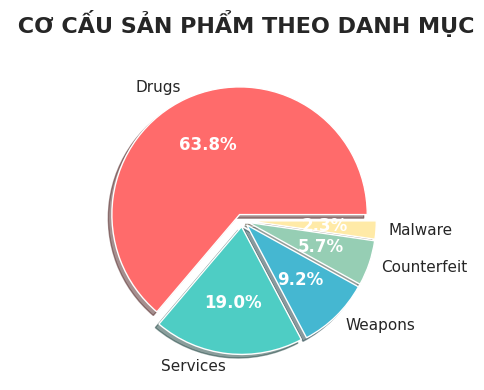


 BIỂU ĐỒ CỘT - SỐ LƯỢNG THEO DANH MỤC
--------------------------------------------------


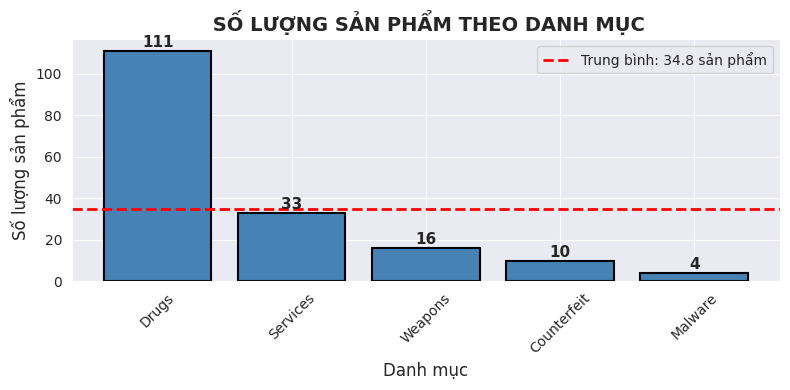


 BIỂU ĐỒ SO SÁNH CÁC DANH MỤC
--------------------------------------------------


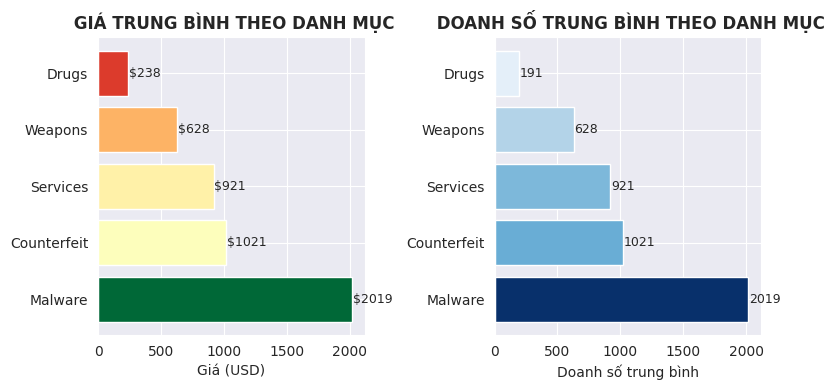

In [342]:
if df.empty:
    print("❌ Không có dữ liệu để phân tích!")
else:
    # BIỂU ĐỒ TRÒN - CƠ CẤU DANH MỤC
    # ============================================================
    print("\n  BIỂU ĐỒ TRÒN - CƠ CẤU DANH MỤC")
    print("-" * 50)

    try:
        fig, ax = plt.subplots(figsize=(8, 4))
        colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7', '#DFE6E9', '#F39C12', '#E74C3C']

        wedges, texts, autotexts = ax.pie(
            category_counts.values,
            labels=category_counts.index,
            autopct='%1.1f%%',
            colors=colors[:len(category_counts)],
            explode=[0.05] * len(category_counts),
            shadow=True,
            textprops={'fontsize': 11}
        )

        for autotext in autotexts:
            autotext.set_color('white')
            autotext.set_fontweight('bold')
            autotext.set_fontsize(12)

        ax.set_title(' CƠ CẤU SẢN PHẨM THEO DANH MỤC', fontsize=16, fontweight='bold', pad=20)
        plt.tight_layout()
        plt.savefig(CHART_DIR / "category_pie_chart.png", dpi=150, bbox_inches='tight')
        plt.show()
    except Exception as e:
        print(f"⚠️ Không thể vẽ biểu đồ tròn: {e}")

    # ============================================================
    #  BIỂU ĐỒ CỘT - SỐ LƯỢNG THEO DANH MỤC
    # ============================================================
    print("\n BIỂU ĐỒ CỘT - SỐ LƯỢNG THEO DANH MỤC")
    print("-" * 50)

    try:
        fig, ax = plt.subplots(figsize=(8, 4))
        bars = ax.bar(category_counts.index, category_counts.values, color='steelblue', edgecolor='black', linewidth=1.5)
        ax.set_title(' SỐ LƯỢNG SẢN PHẨM THEO DANH MỤC', fontsize=14, fontweight='bold')
        ax.set_xlabel('Danh mục', fontsize=12)
        ax.set_ylabel('Số lượng sản phẩm', fontsize=12)
        ax.tick_params(axis='x', rotation=45)

        for bar, count in zip(bars, category_counts.values):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    str(count), ha='center', va='bottom', fontsize=11, fontweight='bold')

        avg_products = category_counts.mean()
        ax.axhline(y=avg_products, color='red', linestyle='--', linewidth=2,
                   label=f'Trung bình: {avg_products:.1f} sản phẩm')
        ax.legend()
        plt.tight_layout()
        plt.savefig(CHART_DIR / "category_bar_chart.png", dpi=150, bbox_inches='tight')
        plt.show()
    except Exception as e:
        print(f" Không thể vẽ biểu đồ cột: {e}")

    # BIỂU ĐỒ SO SÁNH CÁC DANH MỤC
    # ============================================================
    print("\n BIỂU ĐỒ SO SÁNH CÁC DANH MỤC")
    print("-" * 50)

    try:
        fig, axes = plt.subplots(1, 2, figsize=(8, 4))

        # Biểu đồ 1: So sánh giá trung bình
        avg_price_by_cat = df.groupby('category')['price_usd'].mean().sort_values(ascending=False)
        if len(avg_price_by_cat) > 1:
            colors_bar = plt.cm.RdYlGn(avg_price_by_cat.values / avg_price_by_cat.max())
        else:
            colors_bar = ['steelblue']
        bars = axes[0].barh(avg_price_by_cat.index, avg_price_by_cat.values, color=colors_bar)
        axes[0].set_title(' GIÁ TRUNG BÌNH THEO DANH MỤC', fontsize=12, fontweight='bold')
        axes[0].set_xlabel('Giá (USD)')
        for bar, price in zip(bars, avg_price_by_cat.values):
            axes[0].text(price + 5, bar.get_y() + bar.get_height()/2, f'${price:.0f}',
                         va='center', fontsize=9)

        # Biểu đồ 2: So sánh doanh số trung bình
        avg_sales_by_cat = df.groupby('category')['sales'].mean().sort_values(ascending=False)
        if len(avg_sales_by_cat) > 1:
            colors_bar2 = plt.cm.Blues(avg_sales_by_cat.values / avg_sales_by_cat.max())
        else:
            colors_bar2 = ['steelblue']
        bars = axes[1].barh(avg_sales_by_cat.index, avg_sales_by_cat.values, color=colors_bar2)
        axes[1].set_title(' DOANH SỐ TRUNG BÌNH THEO DANH MỤC', fontsize=12, fontweight='bold')
        axes[1].set_xlabel('Doanh số trung bình')
        for bar, sales in zip(bars, avg_sales_by_cat.values):
            axes[1].text(sales + 5, bar.get_y() + bar.get_height()/2, f'{sales:.0f}',
                         va='center', fontsize=9)

        plt.tight_layout()
        plt.savefig(CHART_DIR / "category_comparison.png", dpi=150, bbox_inches='tight')
        plt.show()
    except Exception as e:
        print(f" Không thể vẽ biểu đồ so sánh: {e}")



In [328]:

if df.empty:
    print("❌ Không có dữ liệu để phân tích!")
else:
    #  LƯU BÁO CÁO RA FILE
    # ============================================================
    print("\n LƯU BÁO CÁO RA FILE")
    print("-" * 50)

    # Lưu bảng thống kê ra CSV
    category_stats_csv = df.groupby('category').agg({
        'title': 'count',
        'price_usd': 'mean',
        'sales': 'sum',
        'risk_score': 'mean'
    }).round(2).sort_values('title', ascending=False)
    category_stats_csv.columns = ['Số lượng', 'Giá TB', 'Tổng doanh số', 'Rủi ro TB']
    category_stats_csv.to_csv(OUTPUT_DIR / "category_statistics.csv", encoding='utf-8-sig')
    print(f" Đã lưu: {OUTPUT_DIR / 'category_statistics.csv'}")

    # Lưu báo cáo text
    with open(OUTPUT_DIR / "category_analysis_report.txt", "w", encoding='utf-8') as f:
        f.write("="*80 + "\n")
        f.write("BÁO CÁO PHÂN TÍCH CƠ CẤU DANH MỤC SẢN PHẨM\n")
        f.write("="*80 + "\n\n")

        f.write(f"Tổng số sản phẩm: {len(df)}\n")
        f.write(f"Tổng số danh mục: {df['category'].nunique()}\n")
        if len(category_counts) > 0:
            f.write(f"Danh mục lớn nhất: {category_counts.index[0]} ({category_counts.values[0]} sản phẩm)\n\n")

        f.write("CHI TIẾT TỪNG DANH MỤC:\n")
        f.write("-"*50 + "\n")
        for cat, count in category_counts.items():
            pct = category_pct[cat]
            cat_df = df[df['category'] == cat]
            f.write(f"\n{cat.upper()}:\n")
            f.write(f"  • Số lượng: {count} ({pct:.1f}%)\n")
            f.write(f"  • Giá trung bình: ${cat_df['price_usd'].mean():.2f}\n")
            f.write(f"  • Tổng doanh số: {cat_df['sales'].sum():,}\n")
            f.write(f"  • Điểm rủi ro: {cat_df['risk_score'].mean():.2f}/6\n")

        f.write("\n" + "="*80 + "\n")
        f.write(f"Ngày tạo báo cáo: {datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
        f.write("="*80)

    print(f" Đã lưu: {OUTPUT_DIR / 'category_analysis_report.txt'}")




 LƯU BÁO CÁO RA FILE
--------------------------------------------------
 Đã lưu: processed/category_statistics.csv
 Đã lưu: processed/category_analysis_report.txt


# Top sản phẩm theo từng category

In [329]:
print("\n" + "="*60)
print("STEP 4: TOP PRODUCTS BY CATEGORY")
print("="*60)

for category in df['category'].unique():
    cat_df = df[df['category'] == category]
    if len(cat_df) == 0:
        continue

    print(f"\n {category} ({len(cat_df)} products)")
    print("-" * 40)

    # Top 3 most expensive in this category
    top3 = cat_df.nlargest(10, 'price_usd')[['title', 'price_usd', 'sales']]
    for i, row in top3.iterrows():
        title = row['title'][:45] + "..." if len(row['title']) > 45 else row['title']
        print(f"   • ${row['price_usd']:>7,.2f} | {row['sales']:>5} sales | {title}")


STEP 4: TOP PRODUCTS BY CATEGORY

 Drugs (111 products)
----------------------------------------
   • $3,277.00 |     0 sales | Pure Heroin 0 5G Untouched Straight From The ...
   • $2,019.00 |  2019 sales | Heroin Top Quality
   • $2,019.00 |  2019 sales | High Quality Herion Powder
   • $2,019.00 |  2019 sales | Heroin Liquid
   • $2,019.00 |  2019 sales | Moet And Chandon
   • $2,019.00 |  2019 sales | Buy Brown Heroin Online
   • $2,019.00 |  2019 sales | Heroin From Iran
   • $2,019.00 |  2019 sales | Ransomware Ransomware Builder Master For Begi...
   • $1,887.00 |     0 sales | 0 5Gr Pure Uncut 3 Heroin 90
   • $1,000.00 |  1000 sales | Percocet 1000 Pc 5Mg Endo Star Top Quality St...

 Weapons (16 products)
----------------------------------------
   • $2,019.00 |  2019 sales | Mossberg Scorpion
   • $2,019.00 |  2019 sales | Mossberg Patriot
   • $2,019.00 |  2019 sales | G Force Shotguns
   • $1,012.00 |  1012 sales | CZ 1012 Bronze 12Ga Shotgun
   • $ 930.00 |   930 sales |

# Biểu đồ phân tích chi tiết


BIỂU ĐỒ PHÂN TÍCH THỊ TRƯỜNG


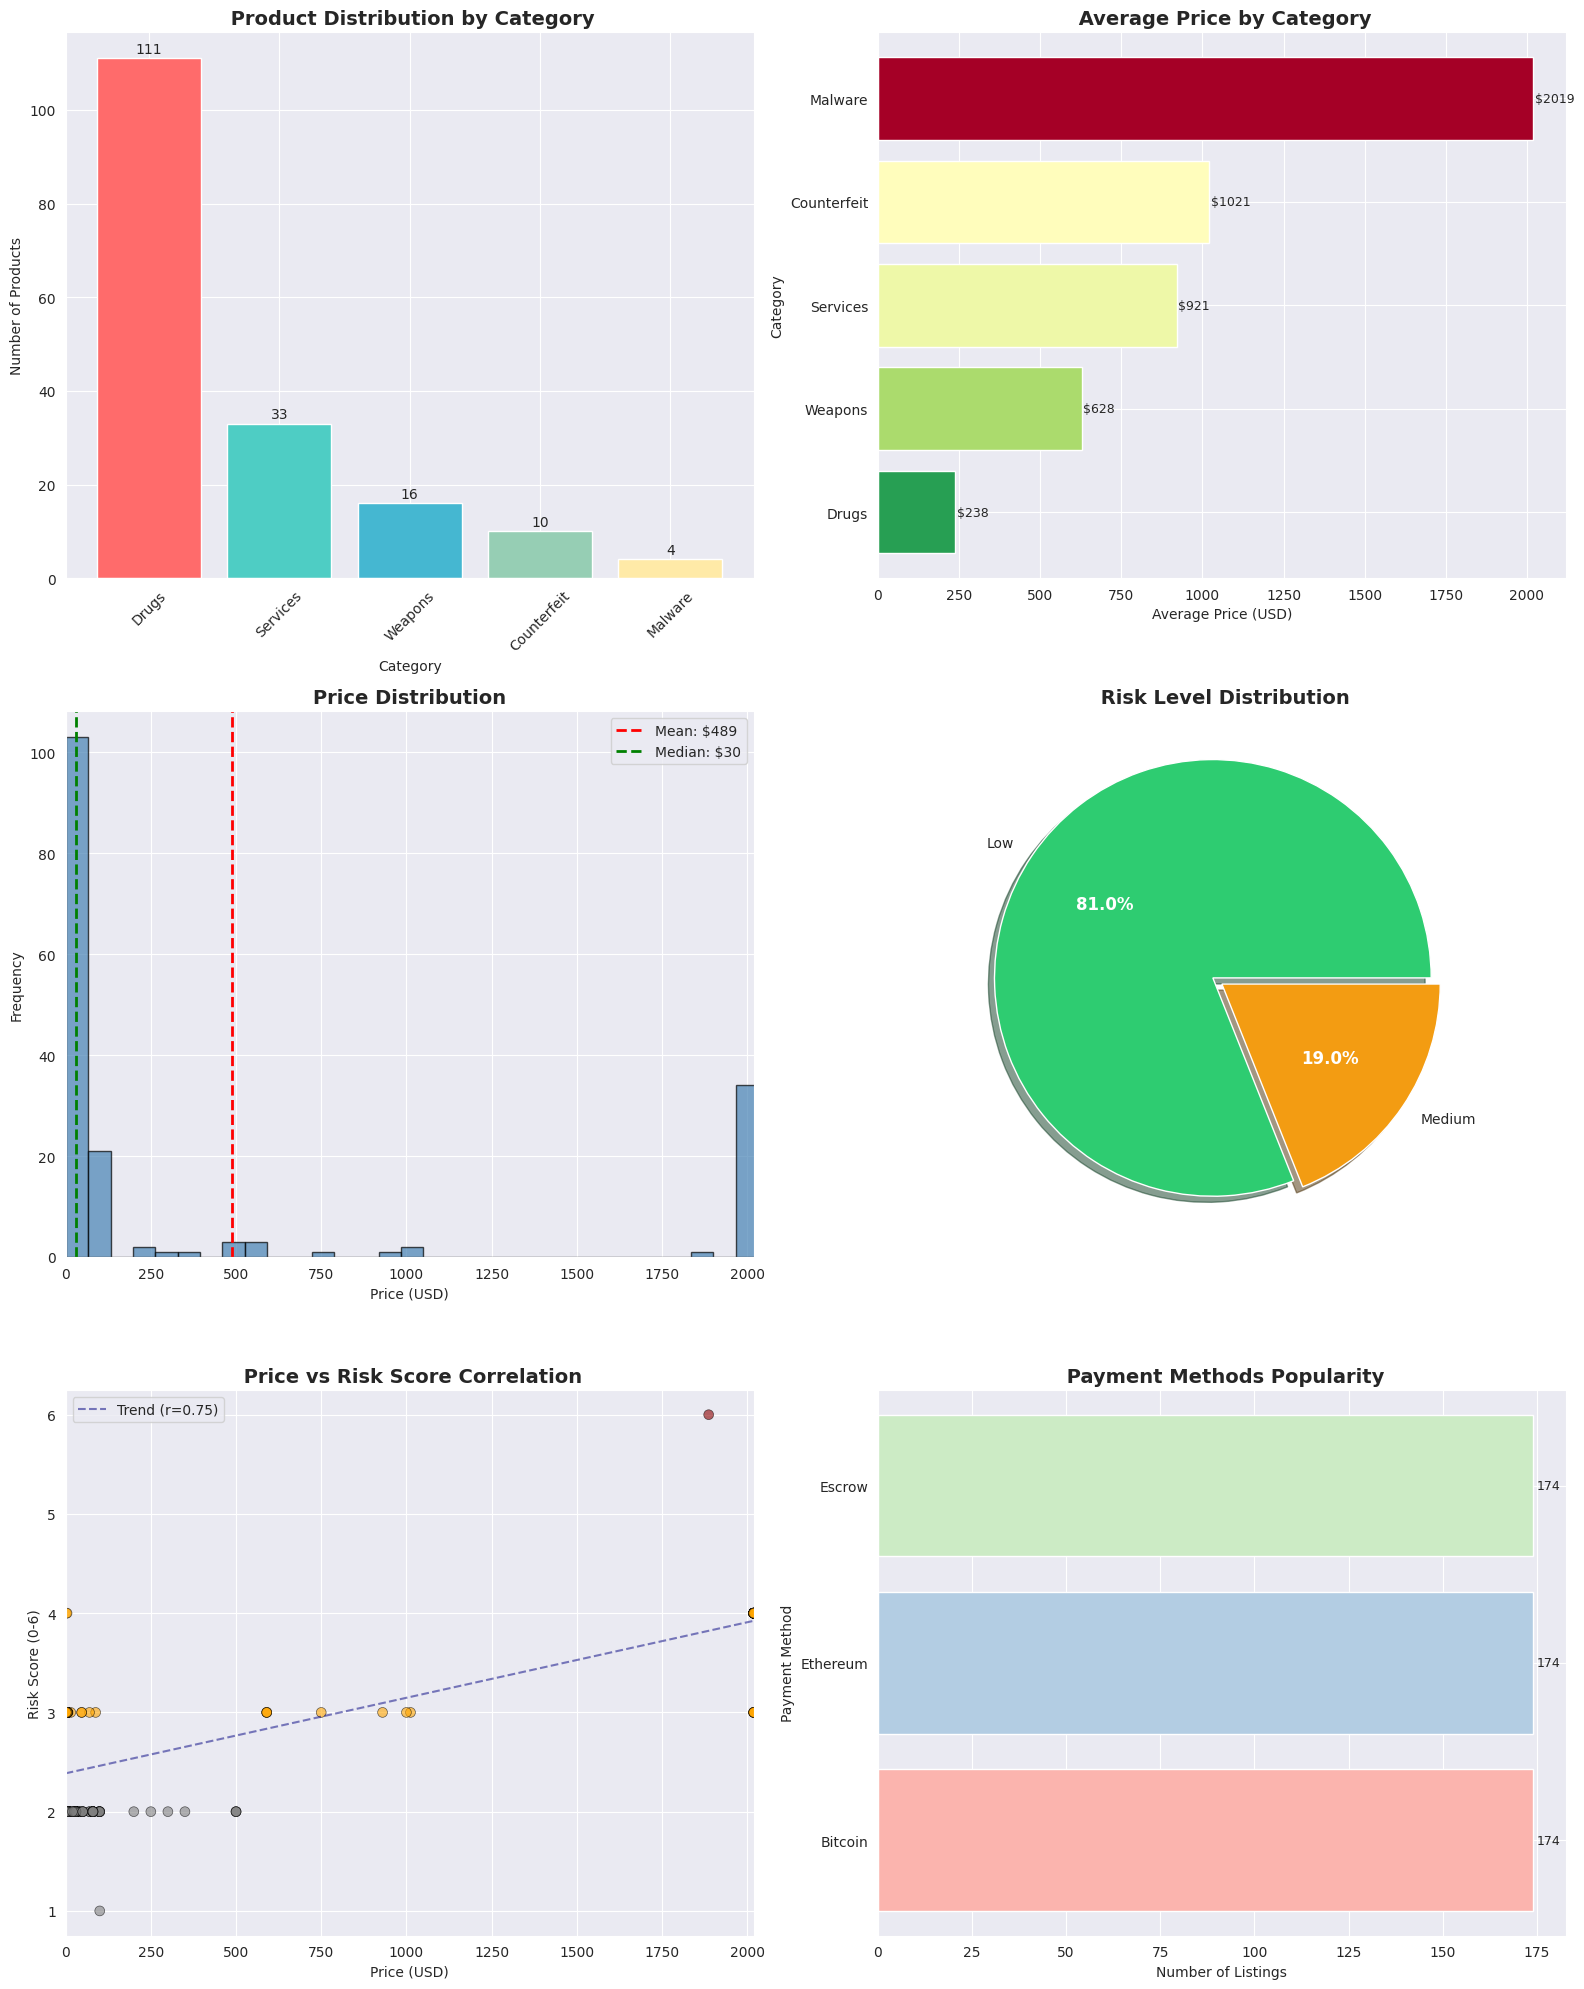

 Market overview chart saved


In [330]:
print("\n" + "="*60)
print("BIỂU ĐỒ PHÂN TÍCH THỊ TRƯỜNG")
print("="*60)

# Tạo figure với nhiều subplots
fig = plt.figure(figsize=(16, 20))

# ============================================================
# 1. Biểu đồ phân bố sản phẩm theo category (Bar chart)
# ============================================================
ax1 = fig.add_subplot(3, 2, 1)
category_counts = df['category'].value_counts()
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7', '#DFE6E9']
bars = ax1.bar(category_counts.index, category_counts.values, color=colors[:len(category_counts)])
ax1.set_title(' Product Distribution by Category', fontsize=14, fontweight='bold')
ax1.set_xlabel('Category')
ax1.set_ylabel('Number of Products')
ax1.tick_params(axis='x', rotation=45)

# Thêm số liệu trên cột
for bar, count in zip(bars, category_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             str(count), ha='center', va='bottom', fontsize=10)

# ============================================================
# 2. Biểu đồ giá trung bình theo category (Horizontal bar)
# ============================================================
ax2 = fig.add_subplot(3, 2, 2)
avg_price = df.groupby('category')['price_usd'].mean().sort_values()
colors_bar = plt.cm.RdYlGn_r(avg_price.values / avg_price.max())
ax2.barh(avg_price.index, avg_price.values, color=colors_bar)
ax2.set_title(' Average Price by Category', fontsize=14, fontweight='bold')
ax2.set_xlabel('Average Price (USD)')
ax2.set_ylabel('Category')

# Thêm giá trị
for i, (cat, price) in enumerate(avg_price.items()):
    ax2.text(price + 5, i, f'${price:.0f}', va='center', fontsize=9)

# ============================================================
# 3. Biểu đồ phân bố giá (Histogram)
# ============================================================
ax3 = fig.add_subplot(3, 2, 3)
ax3.hist(df['price_usd'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
ax3.axvline(df['price_usd'].mean(), color='red', linestyle='--',
            linewidth=2, label=f'Mean: ${df["price_usd"].mean():.0f}')
ax3.axvline(df['price_usd'].median(), color='green', linestyle='--',
            linewidth=2, label=f'Median: ${df["price_usd"].median():.0f}')
ax3.set_title('Price Distribution', fontsize=14, fontweight='bold')
ax3.set_xlabel('Price (USD)')
ax3.set_ylabel('Frequency')
ax3.legend()
ax3.set_xlim(0, df['price_usd'].quantile(0.95))  # Zoom 95% để dễ nhìn

# ============================================================
# 4. Biểu đồ Risk Level Distribution (Pie chart)
# ============================================================
# ============================================================
# 4. Biểu đồ Risk Level Distribution (Pie chart)
# ============================================================
ax4 = fig.add_subplot(3, 2, 4)
risk_colors = {'Low': '#2ECC71', 'Medium': '#F39C12', 'High': '#E74C3C'}
risk_counts = df['risk_level'].value_counts()

# 1. Lấy màu tương ứng, nếu không có trong dict thì để màu xám (gray)
colors_pie = [risk_colors.get(level, 'gray') for level in risk_counts.index]

# 2. SỬA LỖI TẠI ĐÂY: Tạo explode động dựa trên số lượng nhóm thực tế
# Ví dụ: nếu có n nhóm, ta chỉ tách (explode) miếng đầu tiên, còn lại để 0
explode = [0.05] + [0] * (len(risk_counts) - 1)

# 3. Vẽ biểu đồ
wedges, texts, autotexts = ax4.pie(risk_counts.values,
                                   labels=risk_counts.index,
                                   autopct='%1.1f%%',
                                   colors=colors_pie,
                                   explode=explode,  # Bây giờ explode đã khớp độ dài với dữ liệu
                                   shadow=True)

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(12)
    autotext.set_fontweight('bold')
ax4.set_title(' Risk Level Distribution', fontsize=14, fontweight='bold')

# ============================================================
# 5. Biểu đồ Price vs Risk Score (Scatter)
# ============================================================
ax5 = fig.add_subplot(3, 2, 5)
risk_colors_scatter = {0: 'gray', 1: 'gray', 2: 'gray',
                        3: 'orange', 4: 'orange', 5: 'red', 6: 'darkred'}
scatter_colors = [risk_colors_scatter.get(score, 'gray') for score in df['risk_score']]
scatter = ax5.scatter(df['price_usd'], df['risk_score'], c=scatter_colors,
                       alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
ax5.set_title(' Price vs Risk Score Correlation', fontsize=14, fontweight='bold')
ax5.set_xlabel('Price (USD)')
ax5.set_ylabel('Risk Score (0-6)')
ax5.set_xlim(0, df['price_usd'].quantile(0.95))

# Thêm đường xu hướng
from scipy import stats
if len(df) > 1:
    slope, intercept, r_value, p_value, std_err = stats.linregress(df['price_usd'], df['risk_score'])
    x_line = np.array([0, df['price_usd'].quantile(0.95)])
    y_line = slope * x_line + intercept
    ax5.plot(x_line, y_line, '--', color='navy', alpha=0.5,
             label=f'Trend (r={r_value:.2f})')
    ax5.legend()

# ============================================================
# 6. Biểu đồ Top Payment Methods (Bar)
# ============================================================
ax6 = fig.add_subplot(3, 2, 6)
payment_counter = Counter()
for methods in df["payment_method"]:
    for m in methods:
        payment_counter[m] += 1
payment_df = pd.DataFrame(payment_counter.items(), columns=['payment', 'count'])
payment_df = payment_df.sort_values('count', ascending=True)

colors_payment = plt.cm.Pastel1(range(len(payment_df)))
ax6.barh(payment_df['payment'], payment_df['count'], color=colors_payment)
ax6.set_title(' Payment Methods Popularity', fontsize=14, fontweight='bold')
ax6.set_xlabel('Number of Listings')
ax6.set_ylabel('Payment Method')

# Thêm số liệu
for i, (method, count) in enumerate(zip(payment_df['payment'], payment_df['count'])):
    ax6.text(count + 1, i, str(count), va='center', fontsize=9)

plt.tight_layout()
plt.savefig(CHART_DIR / "market_overview.png", dpi=150, bbox_inches='tight')
plt.show()
print(" Market overview chart saved")


CATEGORY DETAILED ANALYSIS


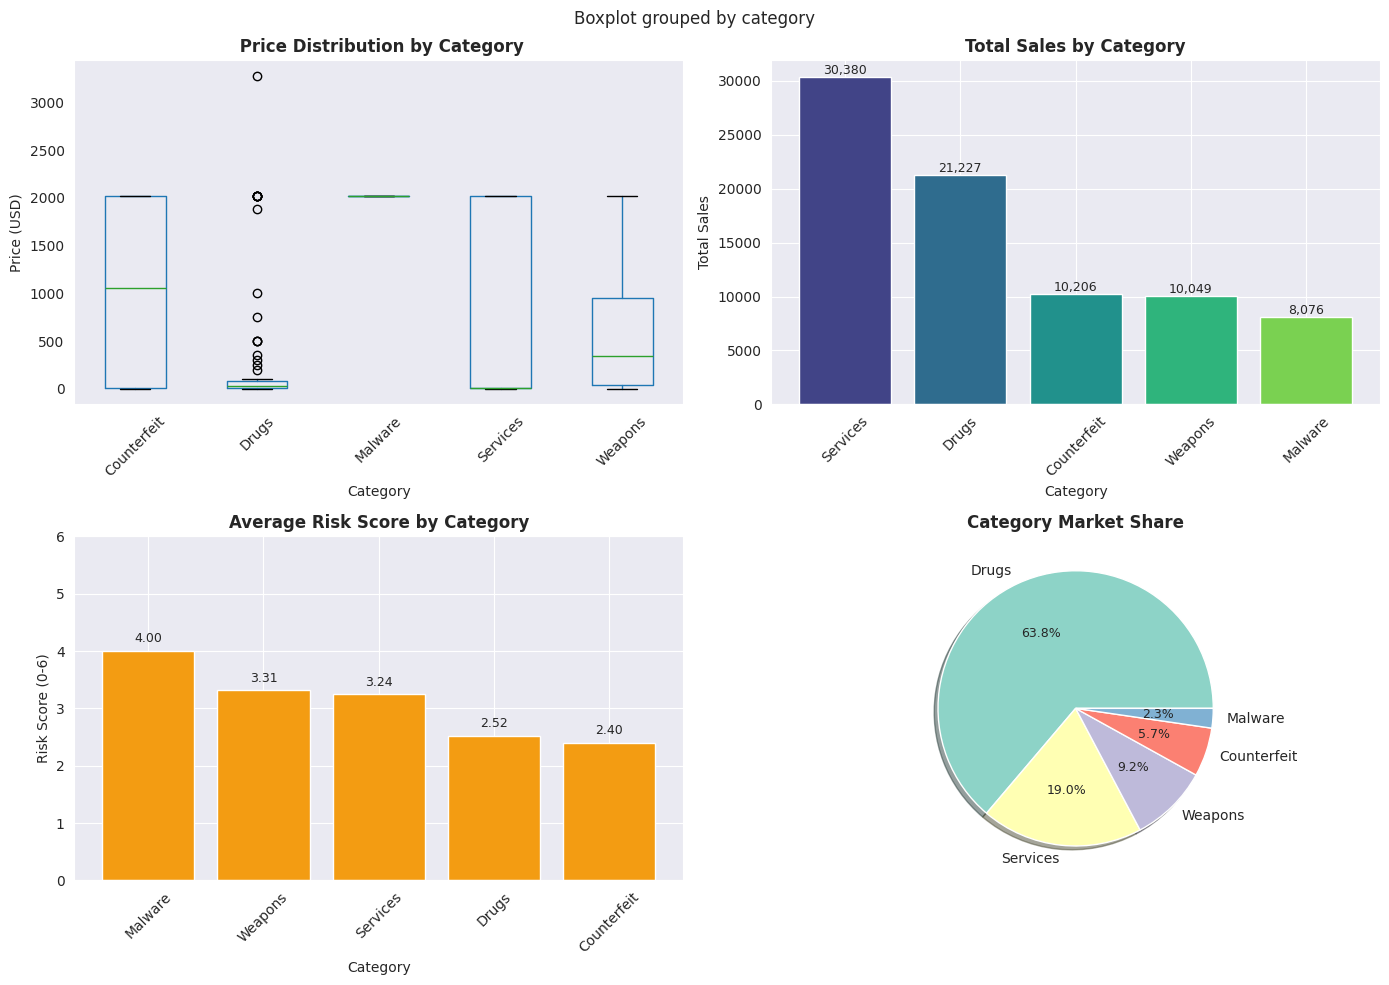

 Category detailed analysis saved


In [331]:
# Biểu đồ phân tích theo category chi tiết
print("\n" + "="*60)
print("CATEGORY DETAILED ANALYSIS")
print("="*60)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ============================================================
# 1. Boxplot: Price distribution by category
# ============================================================
order = df.groupby('category')['price_usd'].median().sort_values(ascending=False).index
df.boxplot(column='price_usd', by='category', ax=axes[0, 0], grid=False)
axes[0, 0].set_title(' Price Distribution by Category', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Category')
axes[0, 0].set_ylabel('Price (USD)')
axes[0, 0].tick_params(axis='x', rotation=45)

# ============================================================
# 2. Bar chart: Total Sales by Category
# ============================================================
sales_by_cat = df.groupby('category')['sales'].sum().sort_values(ascending=False)
colors_sales = plt.cm.viridis(np.linspace(0.2, 0.8, len(sales_by_cat)))
bars = axes[0, 1].bar(sales_by_cat.index, sales_by_cat.values, color=colors_sales)
axes[0, 1].set_title('Total Sales by Category', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Category')
axes[0, 1].set_ylabel('Total Sales')
axes[0, 1].tick_params(axis='x', rotation=45)

# Thêm số liệu
for bar, sales in zip(bars, sales_by_cat.values):
    axes[0, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                    f'{sales:,}', ha='center', va='bottom', fontsize=9)

# ============================================================
# 3. Bar chart: Average Risk Score by Category
# ============================================================
risk_by_cat = df.groupby('category')['risk_score'].mean().sort_values(ascending=False)
colors_risk = ['#E74C3C' if x > 4 else '#F39C12' if x > 2 else '#2ECC71' for x in risk_by_cat.values]
bars = axes[1, 0].bar(risk_by_cat.index, risk_by_cat.values, color=colors_risk)
axes[1, 0].set_title('Average Risk Score by Category', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Category')
axes[1, 0].set_ylabel('Risk Score (0-6)')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].set_ylim(0, 6)

# Thêm số liệu
for bar, score in zip(bars, risk_by_cat.values):
    axes[1, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                    f'{score:.2f}', ha='center', va='bottom', fontsize=9)

# ============================================================
# 4. Pie chart: Category Distribution (Alternative view)
# ============================================================
colors_pie_category = plt.cm.Set3(range(len(category_counts)))
wedges, texts, autotexts = axes[1, 1].pie(category_counts.values,
                                           labels=category_counts.index,
                                           autopct='%1.1f%%',
                                           colors=colors_pie_category,
                                           shadow=True)
for autotext in autotexts:
    autotext.set_fontsize(9)
axes[1, 1].set_title('Category Market Share', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(CHART_DIR / "category_detailed_analysis.png", dpi=150, bbox_inches='tight')
plt.show()
print(" Category detailed analysis saved")


 CORRELATION HEATMAP


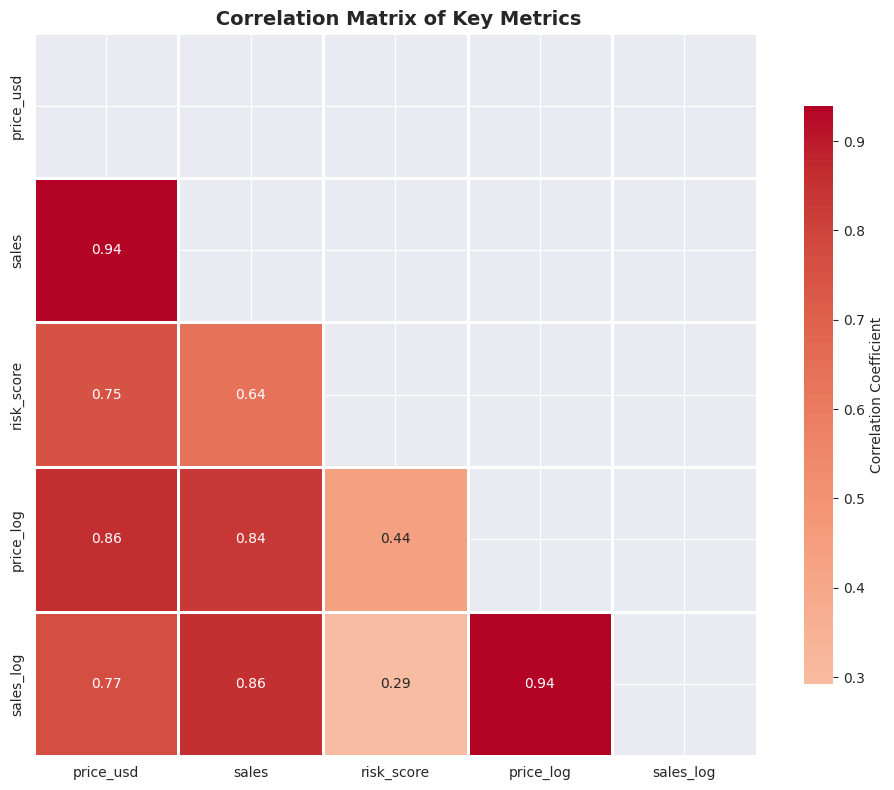

  Correlation heatmap saved


In [332]:
# Biểu đồ Heatmap tương quan
print("\n" + "="*60)
print(" CORRELATION HEATMAP")
print("="*60)

# Chuẩn bị dữ liệu cho correlation
numeric_cols = ['price_usd', 'sales', 'risk_score']
corr_df = df[numeric_cols].copy()

# Thêm log transform để giảm skewness
corr_df['price_log'] = np.log1p(corr_df['price_usd'])
corr_df['sales_log'] = np.log1p(corr_df['sales'])

# Tính correlation matrix
corr_matrix = corr_df.corr()

# Vẽ heatmap
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, fmt='.2f', linewidths=1, mask=mask,
            cbar_kws={'shrink': 0.8, 'label': 'Correlation Coefficient'})
ax.set_title(' Correlation Matrix of Key Metrics', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(CHART_DIR / "correlation_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()
print("  Correlation heatmap saved")


PRICE TREND ANALYSIS


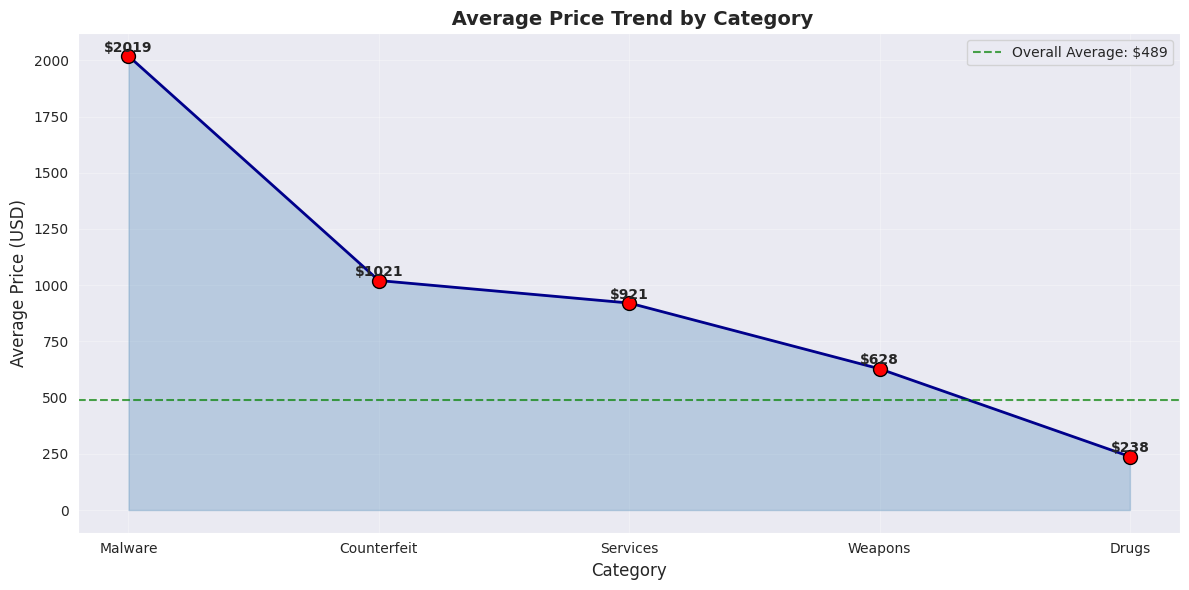

Price trend chart saved


In [333]:
# Biểu đồ Price Trend (Line chart)
print("\n" + "="*60)
print("PRICE TREND ANALYSIS")
print("="*60)

fig, ax = plt.subplots(figsize=(12, 6))

# Tính giá trung bình theo category
price_trend = df.groupby('category')['price_usd'].mean().sort_values(ascending=False)

# Vẽ line chart
ax.plot(price_trend.index, price_trend.values, marker='o', linewidth=2,
        markersize=10, color='darkblue', markerfacecolor='red', markeredgecolor='black')
ax.fill_between(price_trend.index, price_trend.values, alpha=0.3, color='steelblue')

# Thêm giá trị trên điểm
for i, (cat, price) in enumerate(price_trend.items()):
    ax.text(i, price + 20, f'${price:.0f}', ha='center', fontsize=10, fontweight='bold')

ax.set_title(' Average Price Trend by Category', fontsize=14, fontweight='bold')
ax.set_xlabel('Category', fontsize=12)
ax.set_ylabel('Average Price (USD)', fontsize=12)
ax.grid(True, alpha=0.3)

# Thêm đường ngang tham chiếu
avg_all = df['price_usd'].mean()
ax.axhline(y=avg_all, color='green', linestyle='--', alpha=0.7,
           label=f'Overall Average: ${avg_all:.0f}')
ax.legend()

plt.tight_layout()
plt.savefig(CHART_DIR / "price_trend.png", dpi=150, bbox_inches='tight')
plt.show()
print("Price trend chart saved")


 WORD CLOUD FROM PRODUCT DESCRIPTIONS


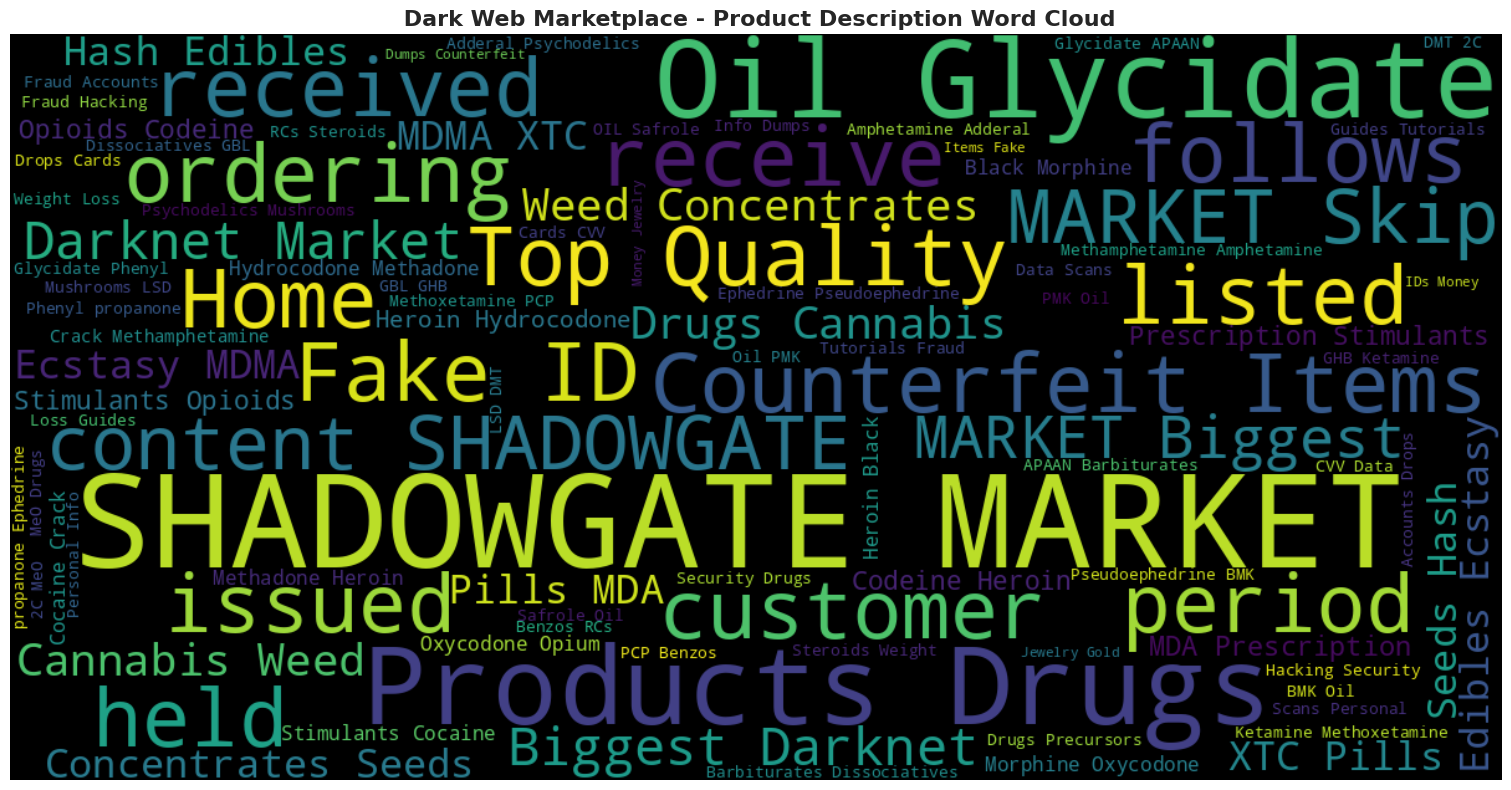

 Word cloud saved


In [334]:
# Biểu đồ Word Cloud từ mô tả sản phẩm
print("\n" + "="*60)
print(" WORD CLOUD FROM PRODUCT DESCRIPTIONS")
print("="*60)

# Gom tất cả text
all_text = " ".join(df["description"].astype(str))

# Tạo word cloud
wordcloud = WordCloud(width=1200, height=600,
                      background_color='black',
                      colormap='viridis',
                      max_words=100,
                      contour_width=1,
                      contour_color='white').generate(all_text)

# Vẽ
plt.figure(figsize=(16, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title(' Dark Web Marketplace - Product Description Word Cloud',
          fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(CHART_DIR / "wordcloud.png", dpi=150, bbox_inches='tight')
plt.show()
print(" Word cloud saved")


 CATEGORY VS RISK LEVEL HEATMAP


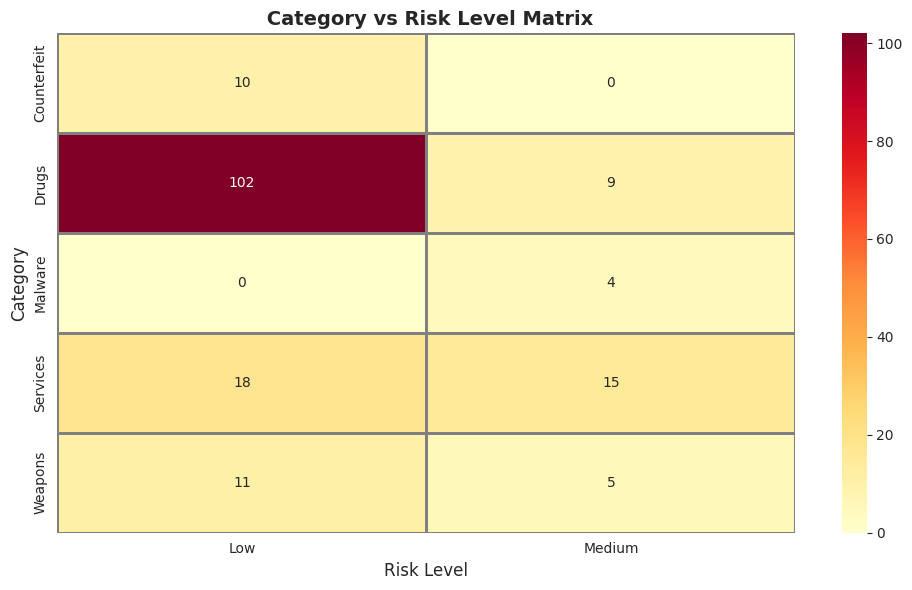

Category-Risk heatmap saved


In [335]:
# Bảng tổng hợp dạng heatmap (Category vs Risk)
print("\n" + "="*60)
print(" CATEGORY VS RISK LEVEL HEATMAP")
print("="*60)

# Tạo ma trận cross-tab
risk_matrix = pd.crosstab(df['category'], df['risk_level'])

# Vẽ heatmap
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(risk_matrix, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=1, linecolor='gray', ax=ax)
ax.set_title(' Category vs Risk Level Matrix', fontsize=14, fontweight='bold')
ax.set_xlabel('Risk Level', fontsize=12)
ax.set_ylabel('Category', fontsize=12)

plt.tight_layout()
plt.savefig(CHART_DIR / "category_risk_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()
print("Category-Risk heatmap saved")


FINAL DASHBOARD - ALL CHARTS


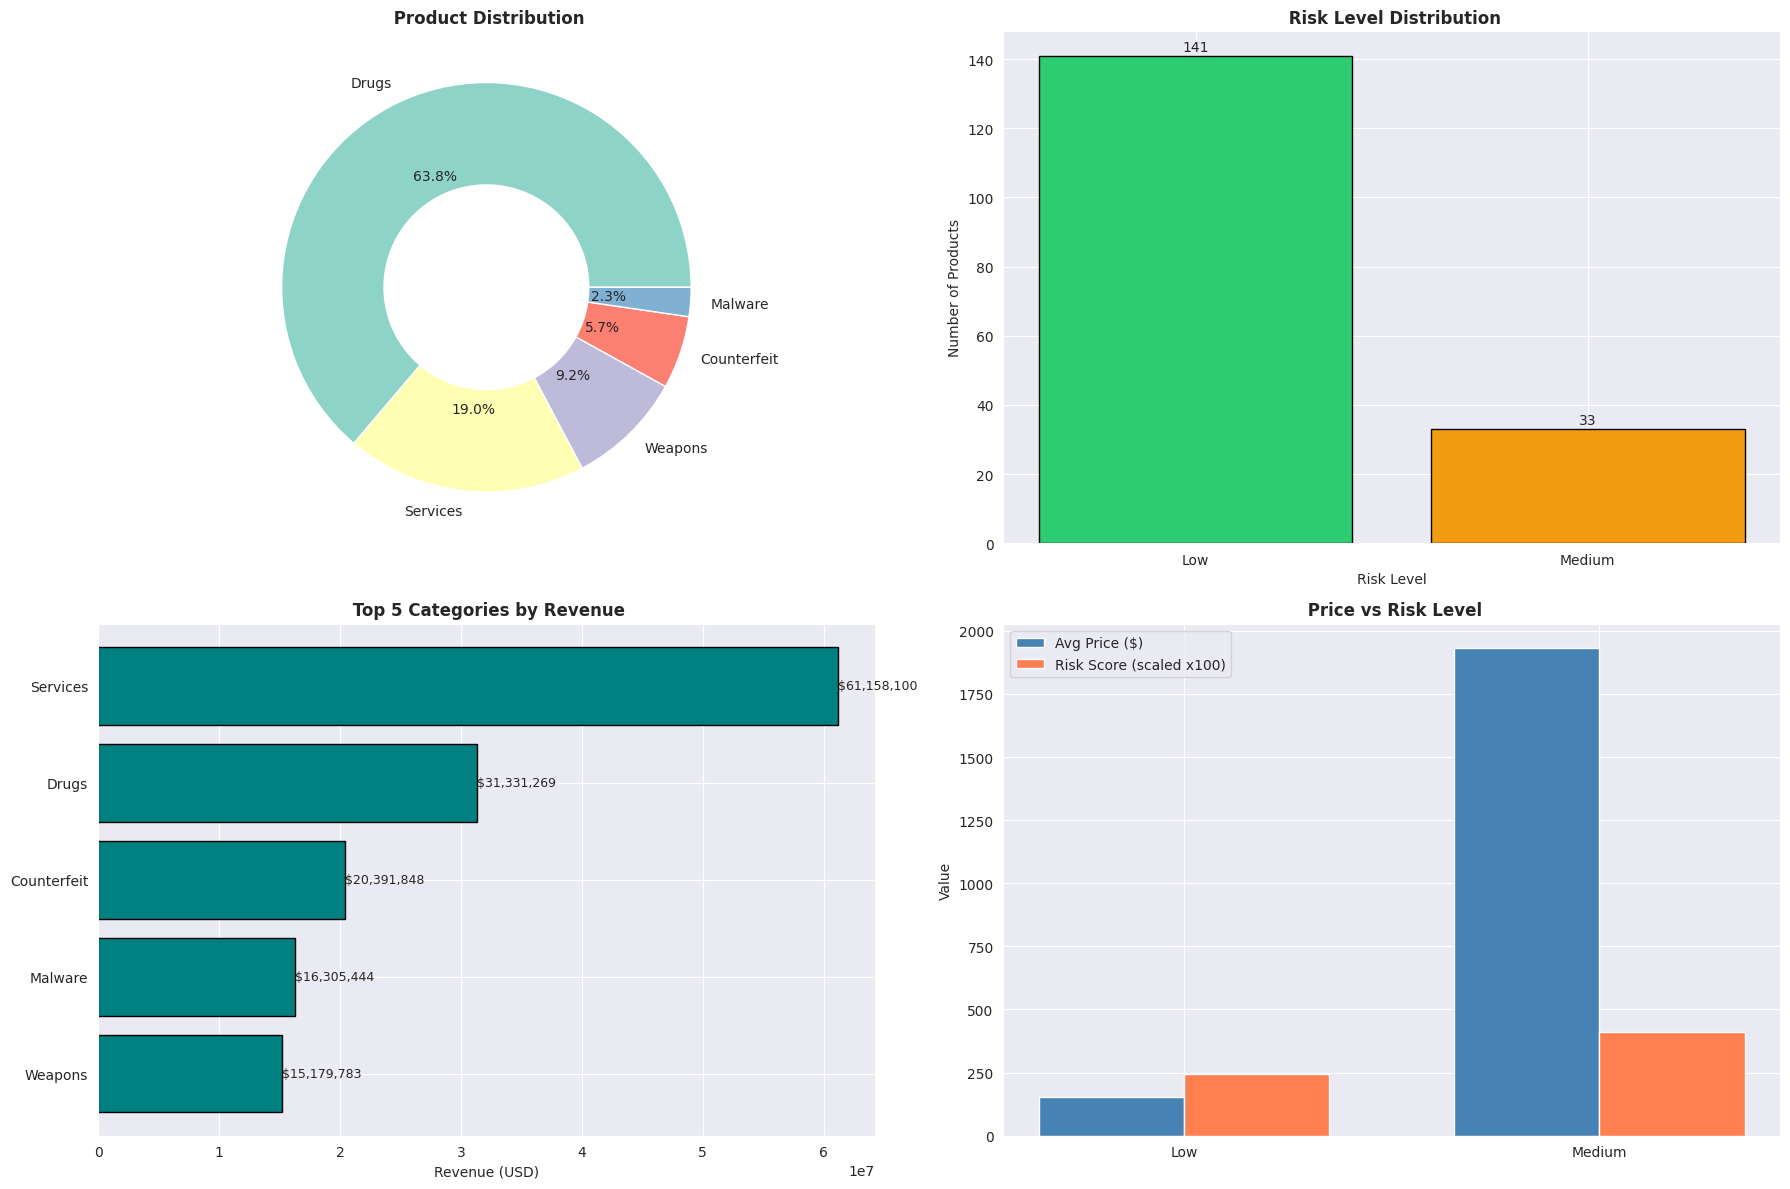

 Final dashboard saved

 ALL VISUALIZATIONS COMPLETED!
 Charts saved to: charts


In [336]:
# Biểu đồ Summary Dashboard (Tổng hợp)
print("\n" + "="*60)
print("FINAL DASHBOARD - ALL CHARTS")
print("="*60)

# Tạo dashboard với 4 biểu đồ chính
fig = plt.figure(figsize=(18, 12))

# 1. Category Distribution (donut chart)
ax1 = fig.add_subplot(2, 2, 1)
category_counts = df['category'].value_counts()
colors_donut = plt.cm.Set3(range(len(category_counts)))
wedges, texts, autotexts = ax1.pie(category_counts.values,
                                     labels=category_counts.index,
                                     autopct='%1.1f%%',
                                     colors=colors_donut,
                                     wedgeprops=dict(width=0.5, edgecolor='white'))
ax1.set_title(' Product Distribution', fontsize=12, fontweight='bold')

# 2. Risk Distribution (bar chart with colors)
ax2 = fig.add_subplot(2, 2, 2)
risk_colors_bar = ['#2ECC71', '#F39C12', '#E74C3C']
risk_dist = df['risk_level'].value_counts()
bars = ax2.bar(risk_dist.index, risk_dist.values, color=risk_colors_bar, edgecolor='black')
ax2.set_title(' Risk Level Distribution', fontsize=12, fontweight='bold')
ax2.set_xlabel('Risk Level')
ax2.set_ylabel('Number of Products')
for bar, count in zip(bars, risk_dist.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             str(count), ha='center', va='bottom', fontsize=10)

# 3. Top 5 Categories by Revenue (horizontal bar)
ax3 = fig.add_subplot(2, 2, 3)
df['revenue'] = df['price_usd'] * df['sales']
revenue_by_cat = df.groupby('category')['revenue'].sum().sort_values(ascending=True).tail(5)
ax3.barh(revenue_by_cat.index, revenue_by_cat.values, color='teal', edgecolor='black')
ax3.set_title(' Top 5 Categories by Revenue', fontsize=12, fontweight='bold')
ax3.set_xlabel('Revenue (USD)')
for i, (cat, revenue) in enumerate(revenue_by_cat.items()):
    ax3.text(revenue + 100, i, f'${revenue:,.0f}', va='center', fontsize=9)

# 4. Average Price vs Risk Score (grouped bar)
ax4 = fig.add_subplot(2, 2, 4)
summary_stats = df.groupby('risk_level').agg({
    'price_usd': 'mean',
    'risk_score': 'mean'
}).round(2)
x = range(len(summary_stats))
width = 0.35
bars1 = ax4.bar([i - width/2 for i in x], summary_stats['price_usd'], width,
                label='Avg Price ($)', color='steelblue')
bars2 = ax4.bar([i + width/2 for i in x], summary_stats['risk_score'] * 100, width,
                label='Risk Score (scaled x100)', color='coral')
ax4.set_xticks(x)
ax4.set_xticklabels(summary_stats.index)
ax4.set_title(' Price vs Risk Level', fontsize=12, fontweight='bold')
ax4.set_ylabel('Value')
ax4.legend()

plt.tight_layout()
plt.savefig(CHART_DIR / "final_dashboard.png", dpi=150, bbox_inches='tight')
plt.show()
print(" Final dashboard saved")
print("\n" + "="*60)
print(" ALL VISUALIZATIONS COMPLETED!")
print(f" Charts saved to: {CHART_DIR}")
print("="*60)

# Phân tích các phương thức thanh toán


PAYMENT METHODS - DETAILED ANALYSIS

 PAYMENT METHODS OVERVIEW
----------------------------------------
   Bitcoin   :  174 listings (100.0%) ██████████████████████████████████████████████████
   Ethereum  :  174 listings (100.0%) ██████████████████████████████████████████████████
   Escrow    :  174 listings (100.0%) ██████████████████████████████████████████████████

    Total listings with payment info: 174
    Total payment mentions: 522
   Average payment methods per listing: 3.00


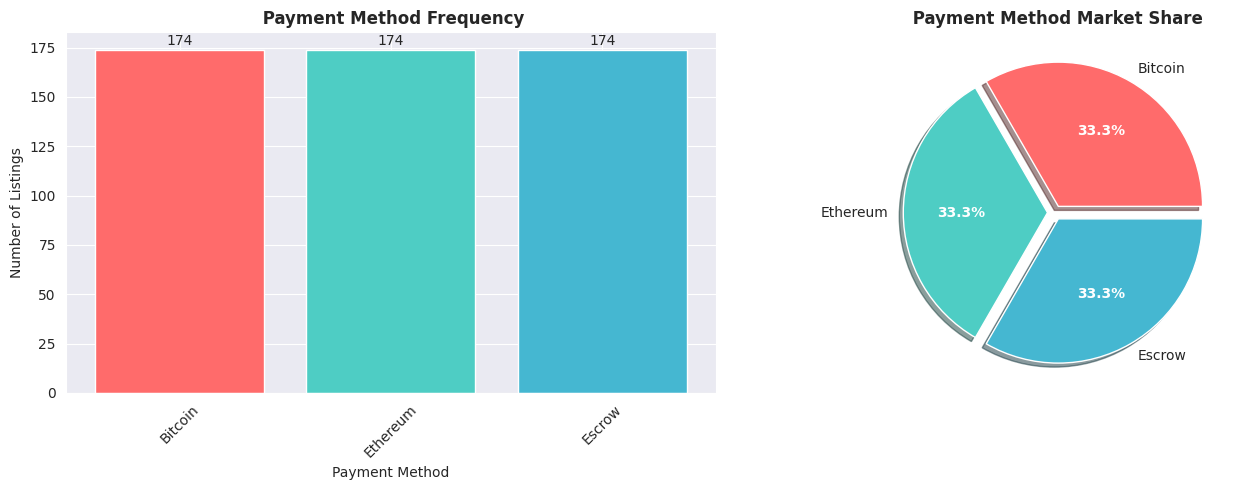

In [337]:
#  Phân tích tổng quan về phương thức thanh toán
print("\n" + "="*60)
print("PAYMENT METHODS - DETAILED ANALYSIS")
print("="*60)

# Tạo DataFrame chi tiết về payment methods
all_payments = df['payment_method'].explode()
payment_counts = all_payments.value_counts()
payment_percent = (payment_counts / len(df) * 100).round(1)

# Tổng quan
print("\n PAYMENT METHODS OVERVIEW")
print("-" * 40)
for method, count in payment_counts.items():
    bar = "█" * int(payment_percent[method] / 2)
    print(f"   {method:<10}: {count:>4} listings ({payment_percent[method]:>5.1f}%) {bar}")

print(f"\n    Total listings with payment info: {len(df)}")
print(f"    Total payment mentions: {sum(payment_counts.values)}")
print(f"   Average payment methods per listing: {sum(payment_counts.values)/len(df):.2f}")

# Biểu đồ thanh toán
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors_payment = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7', '#DFE6E9']
bars = axes[0].bar(payment_counts.index, payment_counts.values, color=colors_payment[:len(payment_counts)])
axes[0].set_title(' Payment Method Frequency', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Payment Method')
axes[0].set_ylabel('Number of Listings')
axes[0].tick_params(axis='x', rotation=45)

for bar, count in zip(bars, payment_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 str(count), ha='center', va='bottom', fontsize=10)

# Pie chart
wedges, texts, autotexts = axes[1].pie(payment_counts.values,
                                        labels=payment_counts.index,
                                        autopct='%1.1f%%',
                                        colors=colors_payment[:len(payment_counts)],
                                        explode=[0.05] * len(payment_counts),
                                        shadow=True)
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
axes[1].set_title(' Payment Method Market Share', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(CHART_DIR / "payment_overview.png", dpi=150, bbox_inches='tight')
plt.show()


PAYMENT METHODS BY CATEGORY

 PAYMENT METHODS DISTRIBUTION BY CATEGORY
--------------------------------------------------
payment_method  Bitcoin  Ethereum  Escrow
Drugs               111       111     111
Weapons              16        16      16
Services             33        33      33
Counterfeit          10        10      10
Malware               4         4       4


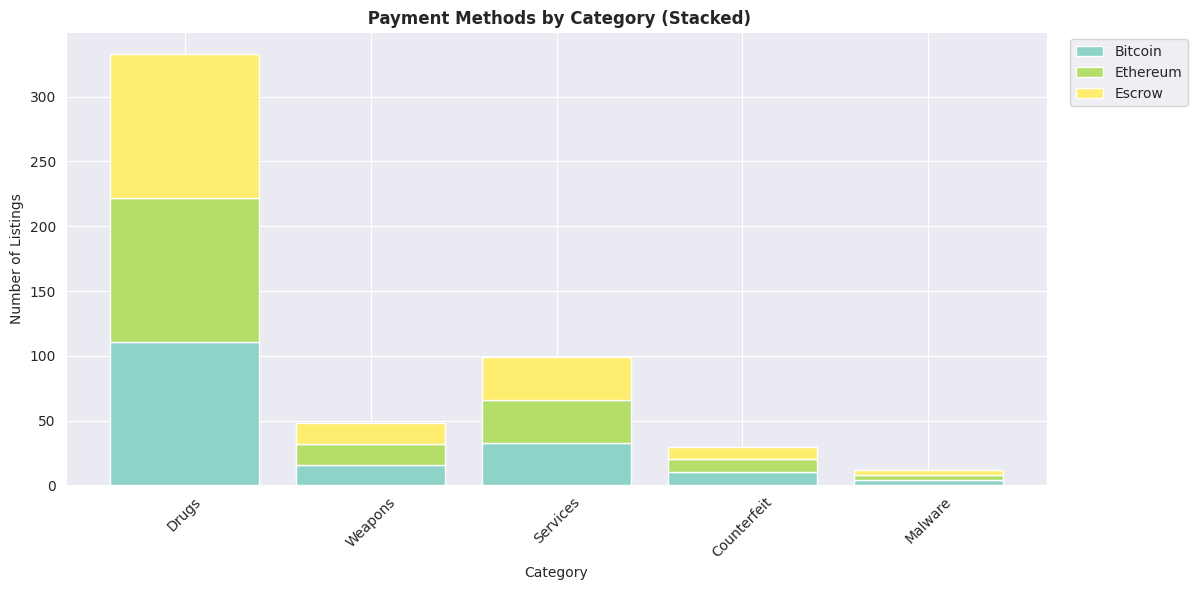

In [339]:
# Phân tích phương thức thanh toán theo Category
print("\n" + "="*60)
print("PAYMENT METHODS BY CATEGORY")
print("="*60)

# Ma trận payment method vs category
payment_by_category = {}
for category in df['category'].unique():
    cat_df = df[df['category'] == category]
    payments = cat_df['payment_method'].explode().value_counts()
    payment_by_category[category] = payments

# Tạo DataFrame cho heatmap
payment_cat_matrix = pd.DataFrame(payment_by_category).fillna(0).T
payment_cat_matrix = payment_cat_matrix[payment_cat_matrix.columns[:5]]  # Top 5 payment methods

print("\n PAYMENT METHODS DISTRIBUTION BY CATEGORY")
print("-" * 50)
print(payment_cat_matrix.to_string())

# Vẽ stacked bar chart
fig, ax = plt.subplots(figsize=(12, 6))

# Chuẩn bị dữ liệu cho stacked bar
categories = payment_cat_matrix.index
payment_methods = payment_cat_matrix.columns
bottom = np.zeros(len(categories))

colors_stacked = plt.cm.Set3(np.linspace(0, 1, len(payment_methods)))

for i, method in enumerate(payment_methods):
    values = payment_cat_matrix[method].values
    ax.bar(categories, values, bottom=bottom, label=method, color=colors_stacked[i])
    bottom += values

ax.set_title(' Payment Methods by Category (Stacked)', fontsize=12, fontweight='bold')
ax.set_xlabel('Category')
ax.set_ylabel('Number of Listings')
ax.legend(loc='upper right', bbox_to_anchor=(1.15, 1))
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(CHART_DIR / "payment_by_category.png", dpi=150, bbox_inches='tight')
plt.show()


 PAYMENT METHOD COMBINATIONS

 MOST COMMON PAYMENT COMBINATIONS
----------------------------------------
   Bitcoin + Ethereum: 174 listings
   Bitcoin + Escrow: 174 listings
   Escrow + Ethereum: 174 listings


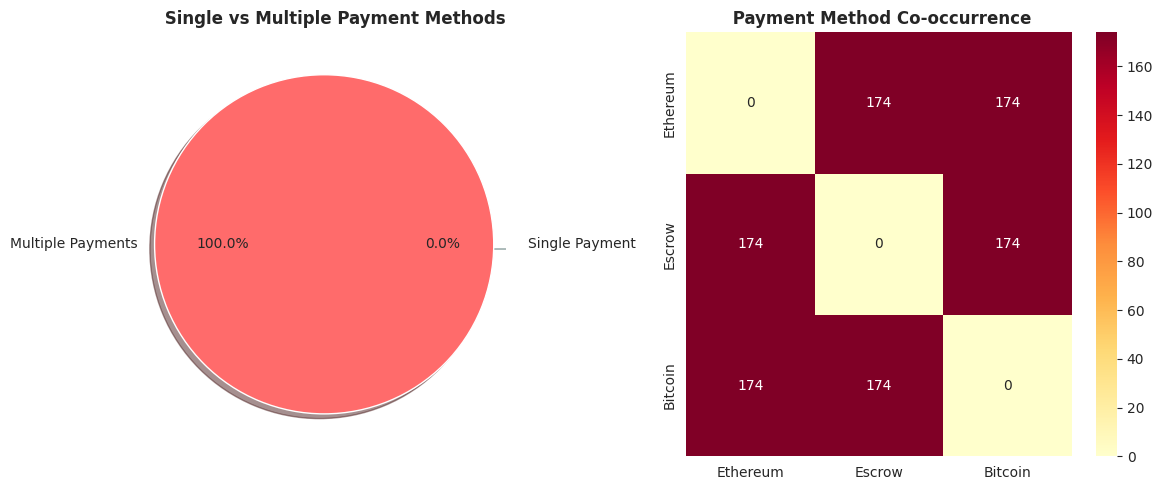

In [340]:
# Phân tích kết hợp thanh toán (Payment Combinations)
print("\n" + "="*60)
print(" PAYMENT METHOD COMBINATIONS")
print("="*60)

# Phân tích các cặp phương thức thanh toán thường đi cùng nhau
payment_pairs = Counter()
for methods in df['payment_method']:
    if len(methods) > 1:
        for i in range(len(methods)):
            for j in range(i+1, len(methods)):
                pair = tuple(sorted([methods[i], methods[j]]))
                payment_pairs[pair] += 1

print("\n MOST COMMON PAYMENT COMBINATIONS")
print("-" * 40)
for pair, count in payment_pairs.most_common(10):
    print(f"   {pair[0]} + {pair[1]}: {count} listings")

# Tính tỷ lệ đơn/đa phương thức
single_payment = sum(1 for m in df['payment_method'] if len(m) == 1)
multi_payment = sum(1 for m in df['payment_method'] if len(m) > 1)

# Vẽ biểu đồ tròn
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Single vs Multi
sizes = [single_payment, multi_payment]
labels = ['Single Payment', 'Multiple Payments']
colors_pie = ['#4ECDC4', '#FF6B6B']
explode = (0.05, 0.05)
axes[0].pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors_pie,
            explode=explode, shadow=True)
axes[0].set_title(' Single vs Multiple Payment Methods', fontsize=12, fontweight='bold')

# Payment combinations heatmap
if len(payment_pairs) > 0:
    # Tạo ma trận kết hợp
    all_methods = list(set([m for pair in payment_pairs.keys() for m in pair]))
    combo_matrix = pd.DataFrame(0, index=all_methods, columns=all_methods)
    for (m1, m2), count in payment_pairs.items():
        combo_matrix.loc[m1, m2] = count
        combo_matrix.loc[m2, m1] = count

    sns.heatmap(combo_matrix, annot=True, cmap='YlOrRd', fmt='d', ax=axes[1])
    axes[1].set_title(' Payment Method Co-occurrence', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(CHART_DIR / "payment_combinations.png", dpi=150, bbox_inches='tight')
plt.show()

# Kết luận


## 1. Tổng quan dữ liệu thu thập
Sau quá trình Crawl và xử lý dữ liệu từ thị trường ShadowGate Market, chúng ta thu được bộ dữ liệu gồm **174 sản phẩm** thuộc nhiều danh mục hàng hóa bất hợp pháp khác nhau.
Quá trình crawl thực tế diễn ra mất khá nhiều thời gian, 

## 2. Các phát hiện chính
* **Danh mục thống trị:** Nhóm Drugs chiếm tỷ trọng cao. Điều này cho thấy đây là mặt hàng chủ đạo và có tính thanh khoản cao nhất trên thị trường này.
* **Cơ cấu giá cả:** Mức giá trung bình của các mặt hàng rơi vào khoảng **$758.5**, tuy nhiên có sự phân hóa mạnh giữa các nhóm hàng kỹ thuật số (Malware, Hacking) và hàng vật lý (Vũ khí, Ma túy).
* **Hệ sinh thái thanh toán:có thể thanh toán bằng Bitcoin, Ethereum, Escrow đảm bảo tính mã hoá và bí mất
    * Hầu hết các nhà cung cấp đều yêu cầu thanh toán qua Escrow (trung gian) để đảm bảo an toàn.
* **Nhà cung cấp nổi bật:** Vendor **NorthStar** xuất hiện với tần suất cao nhất, cho thấy sự tồn tại của các "đại lý" lớn có uy tín cao trong cộng đồng ngầm.

## 3. Đánh giá rủi ro
Dựa trên phân tích tương quan giữa giá và điểm rủi ro (Risk Score):
* Các mặt hàng có rủi ro cao (Vũ khí, Ma túy nồng độ cao) thường đi kèm với các phương thức vận chuyển phức tạp và yêu cầu bảo mật nghiêm ngặt.
* Thị trường cho thấy sự chuyên nghiệp hóa trong cách trình bày, mô tả sản phẩm và hệ thống đánh giá (Rating/Reviews).